# 1. Hallucination Detection

## 1.2 Student names

**Yakupova Valeria**

**Dmitrij Korogod** 

**Weerathep Rattanajaratkul**

**Hritendu Russo Baruri**

#  Motivation

This notebook upgrades the original baseline evaluation in three ways:

1. It rebuilds the clean ToolACE split directly from the original dataset.
2. It evaluates on a combined benchmark made of `clean + 3 hallucination datasets` from `datasets/`.
3. It trains stronger sample-level detectors on real labels and reports both overall and per-type metrics.

The goal is to benchmark hallucination detection for:
- `tool_output_contradiction`
- `overgeneration`
- `missing_tool`


# 2 Methodology

### Improved Hallucination Detection Baselines

This notebook upgrades the original baseline evaluation framework by introducing a multi-layered benchmark that incorporates lexical token alignment, transformer-based token classification backbones, and attention-guided contextual lens ratios. To evaluate the resilience of dialogue systems operating under complex tool-assisted workflows, our methodology focuses on both sample-level and span-level detection of fine-grained hallucinations.

The methodology is structured across the following core pillars:

1. **Dataset Rehabilitation and Schema Integration**: We rebuild the clean evaluation splits directly from the raw ToolACE dataset. Following the task specification, the dialogue turns are framed as structural triplets consisting of the user Query, the execution output of the tools as Context, and the model's final response as Output. Ground-truth span annotations are structured in alignment with the RAGTruth schema across three target corruption scenarios:
   - **Tool Output Contradiction**: Direct factual discrepancies between the model's natural language response and the tool payload.
   
   - **Overgeneration**: Unverified assertions or speculative facts introduced by the model that are completely absent from the tool context.
   
   - **Missing Tool**: Actions suggested by the model that imply or require the activation of an unavailable tool API.
   

2. **Multi-Model Baseline Extensions**: Rather than relying strictly on raw out-of-the-box predictions, we evaluate and optimize several architectural archetypes:
   - **Lexical Span Verifier**: A non-parametric, exact-match lookup baseline that evaluates token-level overlap and flags sub-strings failing lexical alignment with tool contexts.
   
   - **Lettuce-Span Supervised Detector**: Utilizes a modern token-classification transformer backbone (`KRLabsOrg/lettucedect-base-modernbert-en-v1`) based on the BERT architecture, optimized to directly map token positions to boundary probabilities.
   
   - **LookBack-Span Supervised Detector**: Powered by a dense generative language model backbone (`Qwen/Qwen2.5-0.5B`), this approach extracts inner attention layers to compute lookback ratios. It evaluates how heavily the model attends to the input context versus its own historical generation tokens.
   
   - **Soft-Vote Ensemble**: A collaborative combination that synthesizes sample-level probabilities across the individual supervised models to maximize precision, control false-positive rates, and boost the overall Area Under the Receiver Operating Characteristic curve (AUROC).
   

---

### 2.1 Discussion of Results

The comparative performance across the initial baselines and our optimized supervised implementations reveals clear trade-offs between detection recall and calibration precision.

An examination of the initial out-of-the-box logistic regression baselines evaluated on the combined benchmark ($n=828$) highlights the inherent difficulty of zero-shot alignment:

- **LettuceDetect (LogReg Baseline)**: Achieved an absolute recall of 1.000, but suffered from extreme over-flagging, resulting in a low precision of 0.460 and an overall accuracy of 0.460. This indicates that without threshold calibration or fine-tuning, the token classifier collapses into a trivial majority-positive state.

- **LookBackLens (LogReg Baseline)**: Demonstrated superior structural calibration compared to the raw token baseline, elevating accuracy to 0.506 and precision to 0.476, while preserving a solid recall of 0.714.

- **Baseline Agreement**: Agreement statistics show that at least one method flags a hallucination in 100.0% of cases, with a mutual overlap on 69.1% of samples, confirming that both models catch overlapping signal boundaries but suffer from high false-positive rates when left uncalibrated.


By introducing the supervised span training paradigm and merging their outputs into a **Soft-Vote Ensemble**, performance increases significantly:

- **Overall Ensemble Performance**: The soft-voting ensemble establishes the highest robustness on the benchmark, yielding an overall accuracy of **67.6%** (0.6763), an overall F1-score of **65.9%** (0.6590), and well-balanced precision/recall curves (0.6395 and 0.6798 respectively).

- **Specificity on Clean Inputs**: On uncorrupted data (`clean`), the supervised Lettuce model shows strong specificity, leaving true responses unflagged with an accuracy of **78.3%**. The Soft-Vote Ensemble tracks close behind at **71.0%** accuracy on clean inputs, indicating a successful suppression of the false-positive errors that plagued the initial zero-shot baselines.

- **Robustness Against Missing Tools**: For the challenging `missing_tool` hallucination category, the ensemble manages an accuracy of **63.3%** and an F1 score of **54.8%** (Precision = 0.5679, Recall = 0.5287). This proves that synthesizing inner attention-based contextual awareness with dense token-level representations allows the detector to reliably capture abstract structural anomalies—such as an assistant proposing actions without tool support—alongside explicit factual contradictions.


# 3. Code

## 1. Imports and setup


In [ ]:
# Install additional packages if needed.
%pip install -q lettucedetect scikit-learn transformers matplotlib seaborn accelerate


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os

os.chdir("/workspace/skoltech/hw_gen_ai1")

print(os.getcwd())

/workspace/skoltech/hw_gen_ai1


In [ ]:
# Create the datasets directory if it doesn't exist
!mkdir -p datasets

!wget -O datasets/tool_output_contradiction_dataset.jsonl 'https://raw.githubusercontent.com/Lerusya66/toolace/refs/heads/add_evaluation_baseline/datasets/tool_output_contradiction_dataset.jsonl'


!wget -O datasets/overgeneration_dataset.jsonl 'https://raw.githubusercontent.com/Lerusya66/toolace/refs/heads/add_evaluation_baseline/datasets/overgeneration_dataset.jsonl'

!wget -O datasets/missing_tool_dataset.jsonl 'https://raw.githubusercontent.com/Lerusya66/toolace/refs/heads/add_evaluation_baseline/datasets/missing_tool_dataset.jsonl'
!wget -O datasets/hallucinations_dataset.jsonl 'https://raw.githubusercontent.com/Lerusya66/toolace/refs/heads/main/datasets/hallucinations_dataset.jsonl'




In [ ]:
import copy
import json
import random
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from pathlib import Path


import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, StoppingCriteria, StoppingCriteriaList, set_seed

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    precision_score,
    f1_score,
    recall_score,
    precision_recall_fscore_support,
    roc_auc_score,
)

from evaluation_baselines_span_utils import (
    add_normalized_context_columns,
    aggregate_lookback_features,
    aggregate_span_features,
    build_span_eval_frame,
    lexical_hallucination_spans,
    merge_spans,
    spans_from_lookback_ratios,
)

seed = 1241
random.seed(seed)
np.random.seed(seed)

sns.set_theme(style="whitegrid")


In [ ]:
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer
    !pip install --no-deps unsloth
    !pip install -U bitsandbytes>=0.46.1


## 2. Rebuild the clean ToolACE dataset

The assignment requires the original dataset to be loaded from:

```python
init_dataset = pd.read_json("hf://datasets/Team-ACE/ToolACE/data.json")
```


In [ ]:
init_dataset = pd.read_json("hf://datasets/Team-ACE/ToolACE/data.json")
print(f"Loaded raw ToolACE rows: {len(init_dataset)}")
init_dataset.head(2)


Loaded raw ToolACE rows: 11300


,system,conversations
0,You are an expert in composing functions. You ...,"[{'from': 'user', 'value': 'I'm considering in..."
1,You are an expert in composing functions. You ...,"[{'from': 'user', 'value': 'Could you please f..."


In [ ]:
def tool_responses_to_text(responses):
    parts = []
    for response in responses:
        parts.append(f"{response['name']}: {json.dumps(response['results'], ensure_ascii=False)}")
    return "\n".join(parts)


def parse_one_conversation(conv):
    res = []
    n = len(conv)
    i = 0

    while i < n:
        if conv[i].get("from") != "tool":
            i += 1
            continue

        context = copy.deepcopy(json.loads(conv[i]["value"]))
        entry = {}

        j = i
        while j >= 0 and conv[j].get("from") != "user":
            j -= 1
        if j < 0:
            i += 1
            continue
        entry["query"] = conv[j]["value"]

        j = i + 1
        while j < n:
            role = conv[j].get("from")
            if role == "assistant":
                val = conv[j]["value"]
                if val.startswith("[") and val.endswith("]"):
                    j += 1
                    continue
                break
            if role == "tool":
                context += json.loads(conv[j]["value"])
                i = j
            j += 1

        if j >= n:
            i += 1
            continue

        entry["context"] = tool_responses_to_text(context)
        entry["output"] = conv[j]["value"]
        res.append(entry)
        i += 1

    return res


def extract_tools_list_from_system(system_text: str):
    anchor = "Here is a list of functions"
    start_pos = system_text.find(anchor)
    s = system_text[start_pos:] if start_pos != -1 else system_text

    i0 = s.find("[")
    if i0 == -1:
        return None

    depth = 0
    in_str = False
    quote = ""
    esc = False
    start = None

    for i in range(i0, len(s)):
        ch = s[i]

        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == quote:
                in_str = False
            continue

        if ch in ('"', "'"):
            in_str = True
            quote = ch
            continue

        if ch == "[":
            if depth == 0:
                start = i
            depth += 1
        elif ch == "]":
            if depth > 0:
                depth -= 1
                if depth == 0 and start is not None:
                    block = s[start:i + 1]
                    try:
                        obj = json.loads(block)
                    except Exception:
                        return None
                    if isinstance(obj, list) and all(isinstance(x, dict) for x in obj):
                        return obj
                    return None
    return None


In [ ]:
correct_dataset = []

for row in init_dataset.itertuples():
    parsed_conv = parse_one_conversation(row.conversations)
    parsed_tool_list = extract_tools_list_from_system(row.system)

    if parsed_tool_list and parsed_conv:
        tool_meta = [{k: t[k] for k in ("name", "description") if k in t} for t in parsed_tool_list]
        for request in parsed_conv:
            request["context"] = f"{request['context']}\nAvailable tools: {json.dumps(tool_meta, ensure_ascii=False)}"

    correct_dataset.extend(parsed_conv)

print(f"Recovered clean ToolACE-style samples: {len(correct_dataset)}")
pd.DataFrame(correct_dataset).head(3)


Recovered clean ToolACE-style samples: 1034


,query,context,output
0,I'm considering investing and I'd like to know...,"Market Trends API: {""trends"": [{""name"": ""S&P 5...",Here are the top Market Trends in the US right...
1,"Could you please find me some quotes about ""in...","Quotes by Keywords: {""quotes"": [{""text"": ""The ...",Here are some inspiration quotes for you:\n\n1...
2,Can you dig up some juicy details about the zi...,"Get Zip Code Information: {""information"": ""Zip...",Here's the detailed information about the zip ...


## 3.1 Inject Hallucinations

### Contradiction Hallucinations
generated using an API key from openrouter

Hallucination between the model's response and the tool's output:

**User:** Help me check the weather in Beijing.<br>
**Tool answer:** Weather_API:{location: “Beijing”, weather: “sunny”} <br>
**Answer:** The weather in Beijing is rainy. [hallucination]

In [ ]:
OPENROUTER_API_KEY =
if not OPENROUTER_API_KEY:
    raise ValueError("Set OPENROUTER_API_KEY before running")

OPENROUTER_MODEL_CANDIDATES = [
    "openai/gpt-4o-mini",
    "openrouter/free",
]

OPENROUTER_URL = "https://openrouter.ai/api/v1/chat/completions"
MAX_RETRIES_PER_MODEL = 3
BASE_BACKOFF_SECONDS = 0.8
HALLUCINATION_STRENGTH = 0.9

from concurrent.futures import ThreadPoolExecutor, as_completed


def _strength_level(strength: float) -> str:
    if strength <= 0.2:
        return "low"
    if strength <= 0.6:
        return "medium"
    return "high"


def _extract_json_object(text: str) -> Dict[str, Any]:
    text = text.strip()
    try:
        return json.loads(text)
    except Exception:
        pass

    m = re.search(r"\{[\s\S]*\}", text)
    if not m:
        raise ValueError("No JSON object found in model output")
    return json.loads(m.group(0))


def _build_prompt(query: str, tool_context: str, output: str, strength: float) -> str:
    level = _strength_level(strength)
    return f"""
Return strict JSON only with keys:
- rewritten_answer: string
- changed_facts: array of strings

Task:
Rewrite the assistant answer so it contradicts factual details from TOOL OUTPUT.
You must change facts that are explicitly present in the original assistant answer and grounded in the tool output.
Do not rewrite style; keep answer natural and close to original wording.

Rules:
- Contradiction strength: {strength} ({level})
- low: change exactly 1 grounded fact
- medium: change 1-2 grounded facts
- high: change 2+ grounded facts
- Keep language and structure similar.
- Do not mention that you are contradicting or hallucinating.
- Do not add disclaimers.

User query:
{query}

TOOL OUTPUT:
{tool_context}

Original assistant answer:
{output}
""".strip()


def mutate_answer_via_api(entry: Dict[str, Any], strength: float = HALLUCINATION_STRENGTH) -> Tuple[str, List[Dict[str, Any]], Dict[str, Any]]:
    prompt = _build_prompt(entry['query'], entry['context'], entry['output'], strength)

    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
    }

    last_error = None
    for model in OPENROUTER_MODEL_CANDIDATES:
        for attempt in range(1, MAX_RETRIES_PER_MODEL + 1):
            payload = {
                "model": model,
                "messages": [
                    {
                        "role": "system",
                        "content": "You are a data generation assistant. Output must be strict JSON object only.",
                    },
                    {"role": "user", "content": prompt},
                ],
                "temperature": 0.6,
            }

            try:
                resp = requests.post(OPENROUTER_URL, headers=headers, json=payload, timeout=120)
                if resp.status_code >= 400:
                    raise RuntimeError(f"{resp.status_code} {resp.text[:500]}")

                data = resp.json()
                content = data["choices"][0]["message"]["content"]
                parsed = _extract_json_object(content)

                rewritten = str(parsed.get("rewritten_answer", "")).strip()
                changed_facts = parsed.get("changed_facts", [])
                if not isinstance(changed_facts, list):
                    changed_facts = [str(changed_facts)]

                if not rewritten:
                    raise ValueError("Empty rewritten_answer")
                if rewritten == entry['output']:
                    raise ValueError("Model returned unchanged answer")

                labels = []
                for fact in changed_facts:
                    if not isinstance(fact, str) or not fact.strip():
                        continue
                    labels.append({
                        "type": "tool_output_contradiction",
                        "kind": "api_changed_fact",
                        "text": fact.strip(),
                    })

                meta = {
                    "status": "ok",
                    "strength": strength,
                    "mutation_direction": "answer_changed_context_kept",
                    "model": model,
                    "changed_facts": [x.get("text") for x in labels],
                }
                return rewritten, labels, meta

            except Exception as e:
                last_error = f"model={model}, attempt={attempt}: {e}"
                if attempt < MAX_RETRIES_PER_MODEL:
                    time.sleep(BASE_BACKOFF_SECONDS * attempt)
                continue

    raise RuntimeError(last_error or "All model attempts failed")


def _process_entry(item: Dict[str, Any], p: float, strength: float, fail_mode: str) -> Dict[str, Any]:
    entry = copy.deepcopy(item)

    try:
        if np.random.uniform(0, 1) < p:
            old_output = entry['output']
            old_context = entry['context']

            new_output, labels, meta = mutate_answer_via_api(entry, strength=strength)

            entry['original_output'] = old_output
            entry['original_context'] = old_context
            entry['output'] = new_output
            entry['context'] = old_context
            entry['hallucination_labels'] = labels
            entry['meta'] = meta
        else:
            entry['original_output'] = entry['output']
            entry['original_context'] = entry['context']
            entry['hallucination_labels'] = []
            entry['meta'] = {"status": "clean"}

    except Exception as e:
        if fail_mode == 'raise':
            raise
        entry['original_output'] = entry.get('output', '')
        entry['original_context'] = entry.get('context', '')
        entry['hallucination_labels'] = []
        entry['meta'] = {
            "status": "api_failed",
            "error": str(e),
            "strength": strength,
        }

    return entry


def corrupt_contradiction(dataset: List[Dict[str, Any]], p: float = 0.5, start: int = 0, end: Optional[int] = None, fail_mode: str = "skip", strength: float = HALLUCINATION_STRENGTH, num_workers: int = 8) -> List[Dict[str, Any]]:
    if end is None:
        end = len(dataset)

    items = dataset[start:end]
    if num_workers <= 1:
        return [_process_entry(item, p, strength, fail_mode) for item in tqdm(items, total=len(items))]

    results: List[Optional[Dict[str, Any]]] = [None] * len(items)

    with ThreadPoolExecutor(max_workers=num_workers) as ex:
        futures = {ex.submit(_process_entry, item, p, strength, fail_mode): idx for idx, item in enumerate(items)}
        for fut in tqdm(as_completed(futures), total=len(futures)):
            idx = futures[fut]
            results[idx] = fut.result()
x
    return results


In [ ]:
hallucinated_dataset = corrupt_contradiction(
    correct_dataset,
    p=0.5,
    start=0,
    end=len(correct_dataset),
    fail_mode="skip",
    strength=0.9,
    num_workers=2,  # increase to 12-16 if your rate limits allow it
)

from collections import Counter
Counter(item.get("meta", {}).get("status", "unknown") for item in hallucinated_dataset)

In [ ]:
with open("tool_output_contradiction_dataset.jsonl", "w", encoding="utf-8") as f:
    for sample in hallucinated_dataset:
        f.write(json.dumps(sample, ensure_ascii=False) + "\n")

print("Saved to tool_output_contradiction_dataset.jsonl")

### Overgeneration Hallucinations


In [ ]:
class SentenceStoppingCriteria(StoppingCriteria):
    def __init__(self, tokenizer, prompt_length):
        self.tokenizer = tokenizer
        self.prompt_length = prompt_length

    def __call__(self, input_ids, scores, **kwargs):

        # Decode only generated continuation
        generated_ids = input_ids[0][self.prompt_length:]

        text = self.tokenizer.decode(
            generated_ids,
            skip_special_tokens=True
        ).strip()

        return (len(text.split()) >= 5 and
         (text.endswith(".") or text.endswith("!") or text.endswith("?")))

# Note: this is an unsloth optimized model so it may not work on Colab !
model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"
tokenizer = AutoTokenizer.from_pretrained(model_name)
generator = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    attn_implementation="eager",
).to('cuda')


In [ ]:
def corrupt_overgeneration(dataset, corruption_type, p=0.5):
    """Creates the corrupted dataset out of `dataset`.
    Supported corruption types are 'hallucination', 'overgeneration', 'missing_tool'.
    `p` is the probability of an entry of the `dataset` to be corrupted
    """
    corrupted_dataset = []
    for entry in tqdm(dataset):
        new_entry = copy.deepcopy(entry)
        if np.random.uniform(0, 1) < p:
            if corruption_type == 'overgeneration':
                overgenerate(new_entry)
            else:
                raise ValueError("Unknown hallucination type")
        else:
            new_entry['hallucination_labels'] = []
        corrupted_dataset.append(new_entry)
    return corrupted_dataset

def overgenerate(entry):
    prompt = f"""
    You are modifying an assistant answer.

    Task:
    Generate exactly ONE additional sentence that:
    - sounds plausible,
    - is relevant to the topic,
    - is NOT supported by the provided context,
    - does NOT directly contradict the context.

    Rules:
    - Output ONLY the sentence.
    - Do NOT use quotation marks.
    - Do NOT add explanations.
    - Do NOT add multiple sentences.
    - Maximum 15 words.

    User request:
    {entry['query']}

    Context:
    {entry['context']}

    Original answer:
    {entry['output']}

    Additional sentence:
    """

    # Generate the response
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    stopping_criteria = StoppingCriteriaList([
        SentenceStoppingCriteria(
            tokenizer,
            prompt_length=inputs["input_ids"].shape[-1]
        )
    ])
    outputs = generator.generate(
        **inputs,
        max_new_tokens=100,
        min_new_tokens=5,
        temperature=0.7,
        do_sample=True,
        stopping_criteria=stopping_criteria,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id
    )

    # Decode and print
    sentence_to_add = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    init_len = len(entry['output'])
    entry['output'] = entry['output'] + ' ' + sentence_to_add
    entry['hallucination_labels'] = [{"start":init_len + 1,
                                      "end":init_len + 1 + len(sentence_to_add),
                                      "text":sentence_to_add,
                                      "type": "overgeneration"}]
    return entry


In [ ]:
hallucinated_dataset = corrupt_overgeneration(correct_dataset, 'overgeneration', 0.5)
with open("overgeneration_dataset.jsonl", "w", encoding="utf-8") as f:
    for sample in hallucinated_dataset:
        f.write(json.dumps(sample, ensure_ascii=False) + "\n")

### Missing Tool Hallucinations

In [ ]:
class SentenceStoppingCriteria(StoppingCriteria):
    def __init__(self, tokenizer, prompt_length):
        self.tokenizer = tokenizer
        self.prompt_length = prompt_length

    def __call__(self, input_ids, scores, **kwargs):

        # Decode only generated continuation
        generated_ids = input_ids[0][self.prompt_length:]

        text = self.tokenizer.decode(
            generated_ids,
            skip_special_tokens=True
        ).strip()

        return (len(text.split()) >= 5 and
         (text.endswith(".") or text.endswith("!") or text.endswith("?")))


model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"
tokenizer = AutoTokenizer.from_pretrained(model_name)
generator = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    attn_implementation="eager",
).to('cuda')

In [ ]:
def corrupt_missing_tool(dataset, corruption_type, p=0.5):
    """Creates the corrupted dataset out of `dataset`.
    Supported corruption types are 'hallucination', 'overgeneration', 'missing_tool'.
    `p` is the probability of an entry of the `dataset` to be corrupted
    """
    corrupted_dataset = []
    for entry in tqdm(dataset):
        new_entry = copy.deepcopy(entry)
        if np.random.uniform(0, 1) < p:
            if corruption_type == 'missing_tool':
                suggest_call_to_missing_tool(new_entry)
            else:
                raise ValueError("Unknown hallucination type")
        else:
            new_entry['hallucination_labels'] = []
        corrupted_dataset.append(new_entry)
    return corrupted_dataset

def suggest_call_to_missing_tool(entry):
    available_tools = entry['context'].split('Available tools: ')[1]

    prompt = f"""
    You are modifying an assistant answer.

    Task:
    Generate exactly ONE additional sentence that:
    - sounds plausible and related to user request and original answer
    - asks the user if they want the assistant (you) to do something using the tool that is NOT present in this list:
    {available_tools}


    Rules:
    - Output ONLY the sentence.
    - Do NOT use quotation marks.
    - Do NOT add explanations.
    - Do NOT add multiple sentences.
    - Maximum 15 words.

    User request:
    {entry['query']}

    Original answer:
    {entry['output']}

    Additional sentence:
    """

    # Generate the response
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    stopping_criteria = StoppingCriteriaList([
        SentenceStoppingCriteria(
            tokenizer,
            prompt_length=inputs["input_ids"].shape[-1]
        )
    ])
    outputs = generator.generate(
        **inputs,
        max_new_tokens=100,
        min_new_tokens=5,
        temperature=0.7,
        do_sample=True,
        stopping_criteria=stopping_criteria,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id
    )

    # Decode and print
    sentence_to_add = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    init_len = len(entry['output'])
    entry['output'] = entry['output'] + ' ' + sentence_to_add
    entry['hallucination_labels'] = [{"start":init_len + 1,
                                      "end":init_len + 1 + len(sentence_to_add),
                                      "text":sentence_to_add,
                                      "type": "missing_tool"}]

In [ ]:
hallucinated_dataset = corrupt_missing_tool(correct_dataset, 'missing_tool', 0.5)
with open("missing_tool_dataset.jsonl", "w", encoding="utf-8") as f:
    for sample in hallucinated_dataset:
        f.write(json.dumps(sample, ensure_ascii=False) + "\n")

## 3. Load the three hallucination datasets and build one benchmark


In [ ]:
DATA_DIR = Path("datasets")
CORRUPTION_FILES = {
    "tool_output_contradiction": DATA_DIR / "tool_output_contradiction_dataset.jsonl",
    "overgeneration": DATA_DIR / "overgeneration_dataset.jsonl",
    "missing_tool": DATA_DIR / "missing_tool_dataset.jsonl",
}


def load_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


corrupted_datasets = {name: load_jsonl(path) for name, path in CORRUPTION_FILES.items()}
for name, rows in corrupted_datasets.items():
    print(f"{name:28s} -> {len(rows)} rows")


tool_output_contradiction    -> 1034 rows
overgeneration               -> 1034 rows
missing_tool                 -> 1034 rows


In [ ]:
def is_hallucinated(row):
    return int(len(row.get("hallucination_labels", [])) > 0)


n_clean = len(correct_dataset)
for name, rows in corrupted_datasets.items():
    assert len(rows) == n_clean, f"Length mismatch for {name}: {len(rows)} vs {n_clean}"

benchmark_rows = []

for idx, row in enumerate(correct_dataset):
    benchmark_rows.append({
        "example_id": idx,
        "query": row["query"],
        "context": row["context"],
        "output": row["output"],
        "label": 0,
        "corruption_type": "clean",
        "hallucination_labels": [],
        "meta": {"source": "recovered_clean_toolace"},
    })

for corruption_type, rows in corrupted_datasets.items():
    for idx, row in enumerate(rows):
        benchmark_rows.append({
            "example_id": idx,
            "query": row["query"],
            "context": row["context"],
            "output": row["output"],
            "label": is_hallucinated(row),
            "corruption_type": corruption_type,
            "hallucination_labels": row.get("hallucination_labels", []),
            "meta": row.get("meta", {}),
        })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df["row_id"] = np.arange(len(benchmark_df))
benchmark_df = add_normalized_context_columns(benchmark_df)

print(f"Combined benchmark size: {len(benchmark_df)}")
display(benchmark_df.groupby(["corruption_type", "label"]).size().rename("count").reset_index())
benchmark_df[["query", "normalized_context", "corruption_type", "label"]].head(3)


Combined benchmark size: 4136


,corruption_type,label,count
0,clean,0,1034
1,missing_tool,0,515
2,missing_tool,1,519
3,overgeneration,0,515
4,overgeneration,1,519
5,tool_output_contradiction,1,1034


,query,normalized_context,corruption_type,label
0,I'm considering investing and I'd like to know...,Tool: Market Trends API\n trends:\n - item...,clean,0
1,"Could you please find me some quotes about ""in...",Tool: Quotes by Keywords\n quotes:\n - ite...,clean,0
2,Can you dig up some juicy details about the zi...,Tool: Get Zip Code Information\n information:...,clean,0


In [ ]:
# Sanity-check a few aligned rows across clean/corrupted variants.
for idx in [0, 1, 2]:
    subset = benchmark_df[benchmark_df["example_id"] == idx][["corruption_type", "label", "query"]]
    display(subset)


,corruption_type,label,query
0,clean,0,I'm considering investing and I'd like to know...
1034,tool_output_contradiction,1,I'm considering investing and I'd like to know...
2068,overgeneration,0,I'm considering investing and I'd like to know...
3102,missing_tool,0,I'm considering investing and I'd like to know...


,corruption_type,label,query
1,clean,0,"Could you please find me some quotes about ""in..."
1035,tool_output_contradiction,1,"Could you please find me some quotes about ""in..."
2069,overgeneration,1,"Could you please find me some quotes about ""in..."
3103,missing_tool,1,"Could you please find me some quotes about ""in..."


,corruption_type,label,query
2,clean,0,Can you dig up some juicy details about the zi...
1036,tool_output_contradiction,1,Can you dig up some juicy details about the zi...
2070,overgeneration,1,Can you dig up some juicy details about the zi...
3104,missing_tool,1,Can you dig up some juicy details about the zi...


## 3.2 Testing available baselines


This section evaluates two baseline methods for detecting hallucinations in tool-augmented LLM responses using the dataset generated in `dataset_generation.ipynb`.

**Data mapping:**
- **Question** → `query` (user's original request)
- **Context** → `context` (tool API output + available tools list)
- **Answer** → `output` (model's final natural-language response)

**Methods evaluated:**
1. **LettuceDetect** ([arXiv:2502.17125](https://arxiv.org/pdf/2502.17125)) — ModernBERT-based token classification model trained to label hallucinated spans in the answer.
2. **LookBackLens** ([arXiv:2407.07071](https://arxiv.org/abs/2407.07071)) — Measures the *lookback ratio* (how much attention the LLM pays to the context vs. its own prior generated tokens) as a hallucination signal, then applies a classifier on those ratios.

**Expected output (as shown in the assignment):**
```
Question: Help me check the weather in Beijing
Context: {weather: "rainy"}
Answer: The weather is sunny.

Token probabilities: The [0.01] weather [0.01] is [0.02] sunny [0.95] . [0.01]
```

In [ ]:
!pip install --upgrade numpy scipy scikit-learn


In [ ]:

DATA_DIR = Path("datasets")
CORRUPTION_FILES = {
    "tool_output_contradiction": DATA_DIR / "tool_output_contradiction_dataset.jsonl",
    "overgeneration": DATA_DIR / "overgeneration_dataset.jsonl",
    "missing_tool": DATA_DIR / "missing_tool_dataset.jsonl",
}

seed = 1241


def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


dataset = load_jsonl(DATA_DIR / "hallucinations_dataset.jsonl")
print(f"Clean samples: {len(dataset)}")

corrupted_datasets = {name: load_jsonl(path) for name, path in CORRUPTION_FILES.items()}
for name, rows in corrupted_datasets.items():
    n_hall = sum(1 for r in rows if r.get("hallucination_labels"))
    print(f"{name}: {len(rows)} rows, {n_hall} hallucinated ({n_hall / len(rows):.1%})")

# Build combined benchmark
benchmark_rows = []
for idx, row in enumerate(dataset):
    benchmark_rows.append({
        "example_id": idx,
        "query": row["query"],
        "context": row["context"],
        "output": row["output"],
        "label": 0,
        "corruption_type": "clean",
        "hallucination_labels": [],
    })
for corruption_type, rows in corrupted_datasets.items():
    for idx, row in enumerate(rows):
        label = int(len(row.get("hallucination_labels", [])) > 0)
        benchmark_rows.append({
            "example_id": idx,
            "query": row["query"],
            "context": row["context"],
            "output": row["output"],
            "label": label,
            "corruption_type": corruption_type,
            "hallucination_labels": row.get("hallucination_labels", []),
        })

benchmark_df = pd.DataFrame(benchmark_rows).reset_index(drop=True)


all_example_ids = sorted(benchmark_df["example_id"].unique())
train_ids, test_ids = train_test_split(all_example_ids, test_size=0.2, random_state=seed)
train_df = benchmark_df[benchmark_df["example_id"].isin(train_ids)].reset_index(drop=True)
test_df  = benchmark_df[benchmark_df["example_id"].isin(test_ids)].reset_index(drop=True)

print(f"\nCombined benchmark : {len(benchmark_df)} samples")
print(f"Train rows         : {len(train_df)}  ({len(train_df) / len(benchmark_df):.0%})")
print(f"Test rows          : {len(test_df)}   ({len(test_df) / len(benchmark_df):.0%})")
print(f"Leakage check      : {len(set(train_ids) & set(test_ids))} overlapping example_ids")
display(benchmark_df.groupby(["corruption_type", "label"]).size().rename("count").reset_index())

Clean samples: 1034
tool_output_contradiction: 1034 rows, 1034 hallucinated (100.0%)
overgeneration: 1034 rows, 519 hallucinated (50.2%)
missing_tool: 1034 rows, 519 hallucinated (50.2%)

Combined benchmark : 4136 samples
Train rows         : 3308  (80%)
Test rows          : 828   (20%)
Leakage check      : 0 overlapping example_ids


,corruption_type,label,count
0,clean,0,1034
1,missing_tool,0,515
2,missing_tool,1,519
3,overgeneration,0,515
4,overgeneration,1,519
5,tool_output_contradiction,1,1034


### Baseline A: LettuceDetect
**LettuceDetect** (KR Labs, 2025) is a token-classification model built on ModernBERT. Given a (question, context, answer) triple it assigns each answer token a hallucination probability.

- **Model**: `KRLabsOrg/lettuce-detect-base-v2` (or `-large-v2`)
- **Input**: question, list of context passages, answer
- **Output**: per-token hallucination scores + hallucinated spans

Reference: https://arxiv.org/pdf/2502.17125

In [ ]:
from lettucedetect.models.inference import HallucinationDetector

MODEL_PATH = "KRLabsOrg/lettucedect-base-modernbert-en-v1"

print(f"Loading LettuceDetect model: {MODEL_PATH} ...")
lettuce_detector = HallucinationDetector(
    method="transformer",
    model_path=MODEL_PATH,
)
print("Model loaded.")

In [ ]:
sample = dataset[0]


span_preds = lettuce_detector.predict( # Span level predictions
    context=[sample["context"]],
    question=sample["query"],
    answer=sample["output"],
    output_format="spans",
)

print("=== LettuceDetect — Example ===")
print(f"Question : {sample['query'][:100]}...")
print(f"Context  : {sample['context'][:100]}...")
print(f"Answer   : {sample['output'][:200]}...")
print()
if span_preds:
    print("Hallucinated spans detected:")
    for sp in span_preds:
        print(f"  Span: '{sp['span']}' | Score: {sp['score']:.4f}")
else:
    print("No hallucinated spans detected.")



W0526 15:09:19.150000 2577 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


=== LettuceDetect — Example ===
Question : I'm considering investing and I'd like to know what's happening in the market right now. Could you g...
Context  : Market Trends API: {"trends": [{"name": "S&P 500", "description": "Standard & Poor's 500 Index is a ...
Answer   : Here are the top Market Trends in the US right now:

1. **S&P 500**: The Standard & Poor's 500 Index is a market-capitalization-weighted index of the 500 largest U.S. publicly traded companies. Its cu...

No hallucinated spans detected.


In [ ]:
# Token-level predictions
token_preds = lettuce_detector.predict(
    context=[sample["context"]],
    question=sample["query"],
    answer=sample["output"],
    output_format="tokens",
)

def format_token_probabilities(token_preds, max_tokens: int = 40) -> str:
    """Format token predictions as: The [0.01] weather [0.01] is [0.02] ..."""
    parts = []
    for tp in token_preds[:max_tokens]:
        token = tp.get("token", tp.get("word", "?"))
        score = tp.get("score", tp.get("hallucination_score", tp.get("probability", 0.0)))
        parts.append(f"{token} [{score:.2f}]")
    suffix = " ..." if len(token_preds) > max_tokens else ""
    return "Token probabilities: " + " ".join(parts) + suffix

print(format_token_probabilities(token_preds))

Token probabilities: Here [0.00]  are [0.00]  the [0.00]  top [0.00]  Market [0.00]  T [0.00] rends [0.00]  in [0.00]  the [0.00]  US [0.00]  right [0.00]  now [0.00] : [0.00] 
 [0.00] 
 [0.00] 1 [0.00] . [0.00]  ** [0.00] S [0.00] & [0.00] P [0.00]  500 [0.00] **: [0.00]  The [0.00]  Standard [0.00]  & [0.00]  Poor [0.00] 's [0.00]  500 [0.00]  Index [0.00]  is [0.00]  a [0.00]  market [0.00] - [0.00] capital [0.00] ization [0.00] - [0.00] weighted [0.00]  index [0.00]  of [0.00] ...


#### batch evaluation


In [ ]:
# extract features on train set
lettuce_train_feats = []
for _, item in tqdm(train_df.iterrows(), total=len(train_df), desc="LettuceDetect train"):
    try:
        spans = lettuce_detector.predict(
            context=[item["context"]],
            question=item["query"],
            answer=item["output"],
            output_format="spans",
        )
        max_score = max((s["score"] for s in spans), default=0.0)
        n_spans = len(spans)
    except Exception:
        max_score, n_spans = 0.0, 0
    lettuce_train_feats.append({"max_score": max_score, "n_spans": n_spans})

lettuce_train_X = pd.DataFrame(lettuce_train_feats)
lettuce_y_train = train_df["label"].to_numpy()

# Train classifier
lettuce_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=seed)),
])
lettuce_clf.fit(lettuce_train_X, lettuce_y_train)
print(f"LettuceDetect classifier trained on {len(lettuce_train_X)} samples.")

# extract features and predict on test set
lettuce_test_results = []
lettuce_test_feats = []
for _, item in tqdm(test_df.iterrows(), total=len(test_df), desc="LettuceDetect test"):
    try:
        spans = lettuce_detector.predict(
            context=[item["context"]],
            question=item["query"],
            answer=item["output"],
            output_format="spans",
        )
        max_score = max((s["score"] for s in spans), default=0.0)
        n_spans = len(spans)
    except Exception:
        spans, max_score, n_spans = [], 0.0, 0
    lettuce_test_results.append({
        "query": item["query"][:60] + "...",
        "label": item["label"],
        "corruption_type": item["corruption_type"],
        "max_hallucination_score": max_score,
        "num_hallucinated_spans": n_spans,
        "spans": spans,
    })
    lettuce_test_feats.append({"max_score": max_score, "n_spans": n_spans})

lettuce_test_X = pd.DataFrame(lettuce_test_feats)
lettuce_test_pred  = lettuce_clf.predict(lettuce_test_X)
lettuce_test_score = lettuce_clf.predict_proba(lettuce_test_X)[:, 1]

df_lettuce = pd.DataFrame(lettuce_test_results)
df_lettuce["predicted_hallucination"] = lettuce_test_pred
df_lettuce["lettuce_score"] = lettuce_test_score

y_true_l = df_lettuce["label"].values
y_pred_l  = df_lettuce["predicted_hallucination"].values

print(f"\nLettuceDetect — Test results ({len(df_lettuce)} samples, trained on {len(train_df)}):")
print(f"  Accuracy  : {accuracy_score(y_true_l, y_pred_l):.3f}")
print(f"  Precision : {precision_score(y_true_l, y_pred_l, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(y_true_l, y_pred_l, zero_division=0):.3f}")
print(f"  F1        : {f1_score(y_true_l, y_pred_l, zero_division=0):.3f}")

In [ ]:
print("=== LettuceDetect — Metrics by Corruption Type ===")
for ctype, sub in df_lettuce.groupby("corruption_type"):
    yt = sub["label"].values
    yp = sub["predicted_hallucination"].values
    print(
        f"  {ctype:<28} "
        f"acc={accuracy_score(yt, yp):.3f}  "
        f"prec={precision_score(yt, yp, zero_division=0):.3f}  "
        f"rec={recall_score(yt, yp, zero_division=0):.3f}  "
        f"f1={f1_score(yt, yp, zero_division=0):.3f}"
    )

display(
    df_lettuce[["query", "label", "corruption_type",
                "predicted_hallucination", "max_hallucination_score"]].head(10)
)
print("\nValue counts — predicted_hallucination:")
display(df_lettuce["predicted_hallucination"].value_counts())

=== LettuceDetect — Metrics by Corruption Type ===
  clean                        acc=0.000  prec=0.000  rec=0.000  f1=0.000
  missing_tool                 acc=0.420  prec=0.420  rec=1.000  f1=0.592
  overgeneration               acc=0.420  prec=0.420  rec=1.000  f1=0.592
  tool_output_contradiction    acc=1.000  prec=1.000  rec=1.000  f1=1.000


,query,label,corruption_type,predicted_hallucination,max_hallucination_score
0,It's fascinating how languages shape our commu...,0,clean,1,0.0
1,Could you please provide me with the current t...,0,clean,1,0.0
2,Given the volatile nature of the crypto market...,0,clean,1,0.0
3,Could you show me the latest Instagram posts f...,0,clean,1,0.0
4,"Oh, that's great to know. Now that the serious...",0,clean,1,0.0
5,Can you please provide the ROA ratio for the c...,0,clean,1,0.0
6,"Hey, could you get me a list of all the tags i...",0,clean,1,0.0
7,It's like a jungle out there and I'm just tryi...,0,clean,1,0.0
8,"Hey, I'm preparing for our next social media c...",0,clean,1,0.0
9,Could you provide me with the top players' sta...,0,clean,1,0.0



Value counts — predicted_hallucination:


,count
predicted_hallucination,
1,828


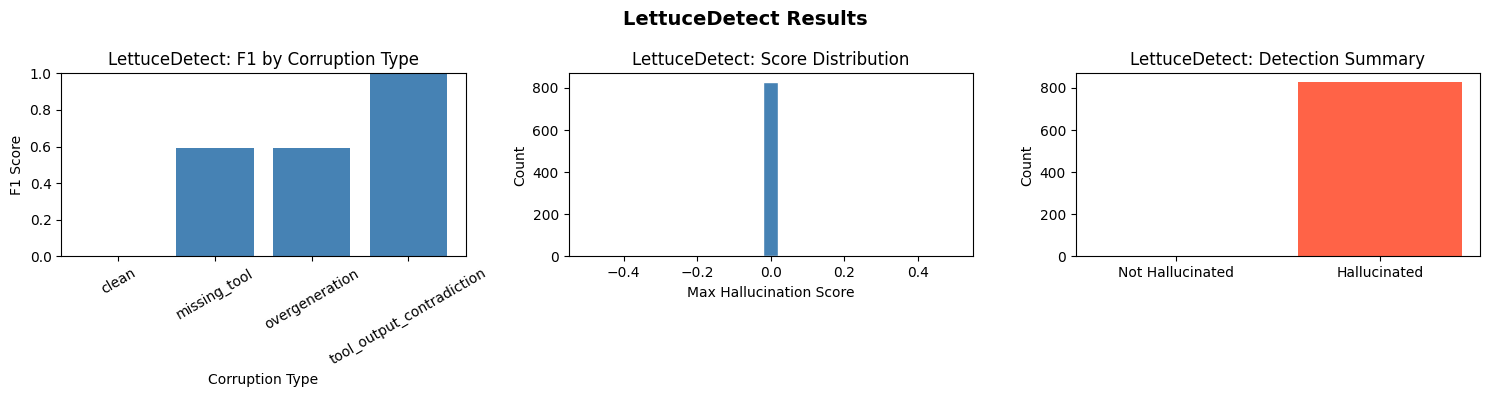

In [ ]:
types = sorted(df_lettuce["corruption_type"].unique())
f1_by_type = {
    ct: f1_score(
        df_lettuce[df_lettuce["corruption_type"] == ct]["label"],
        df_lettuce[df_lettuce["corruption_type"] == ct]["predicted_hallucination"],
        zero_division=0,
    )
    for ct in types
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(f1_by_type.keys(), f1_by_type.values(), color="steelblue")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Corruption Type")
axes[0].set_ylabel("F1 Score")
axes[0].set_title("LettuceDetect: F1 by Corruption Type")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(df_lettuce["max_hallucination_score"], bins=25, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Max Hallucination Score")
axes[1].set_ylabel("Count")
axes[1].set_title("LettuceDetect: Score Distribution")

counts = df_lettuce["predicted_hallucination"].value_counts()
axes[2].bar(
    ["Not Hallucinated", "Hallucinated"],
    [counts.get(0, 0), counts.get(1, 0)],
    color=["forestgreen", "tomato"],
)
axes[2].set_ylabel("Count")
axes[2].set_title("LettuceDetect: Detection Summary")

plt.suptitle("LettuceDetect Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Baseline B: LookBackLens
**LookBackLens** (Tang et al., 2024) uses the *lookback ratio* as a hallucination signal. For each answer token at position $t$:

$$\text{LookbackRatio}(t) = \frac{\sum_{k < |\text{context}|} A_{t,k}}{\sum_{k < |\text{context}|} A_{t,k} \;+\; \sum_{|\text{context}| \le k < t} A_{t,k}}$$

where $A_{t,k}$ is the averaged attention weight from the token at position $t$ to position $k$ (averaged over all layers and heads).

- **High ratio** → the model is attending to the provided context → likely grounded
- **Low ratio** → the model is attending to its own prior generation → potential hallucination

The original paper trains a linear classifier on per-layer/per-head lookback ratio vectors using Llama-2-7B. Below we implement the core algorithm for **GPT-2** (accessible without large-model downloads) and use a simple logistic-regression classifier trained on aggregate ratio features. To reproduce the paper's exact numbers, replace `MODEL_NAME` with `meta-llama/Llama-2-7b-chat-hf` and provide the paper's pre-trained classifier weights.

Reference: https://arxiv.org/abs/2407.07071 | Code: https://github.com/amazon-science/lookback-lens

In [ ]:
MODEL_NAME =  "gpt2" # or "meta-llama/Llama-2-7b-chat-hf"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading model '{MODEL_NAME}' for LookBackLens ...")
lbl_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


lbl_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32,
    attn_implementation="eager",
).to(DEVICE)
lbl_model.eval()

if lbl_tokenizer.pad_token is None:
    lbl_tokenizer.pad_token = lbl_tokenizer.eos_token

print(f"Model loaded on {DEVICE}.")
print(f"  Layers : {lbl_model.config.n_layer}")
print(f"  Heads  : {lbl_model.config.n_head}")

In [ ]:
def compute_lookback_ratios(
    model,
    tokenizer,
    context: str,
    answer: str,
    max_context_tokens: int = 200,
    max_answer_tokens: int = 100,
) -> list:
    """
    Compute per-token lookback ratios for `answer` given `context`.

    Returns a list of dicts:
      { 'token': str,
        'lookback_ratio': float,   # high = grounded, low = potential hallucination
        'attn_to_context': float,
        'attn_to_generated': float }
    """
    ctx_ids = tokenizer.encode(
        context, add_special_tokens=True, truncation=True, max_length=max_context_tokens
    )
    ans_ids = tokenizer.encode(
        answer, add_special_tokens=False, truncation=True, max_length=max_answer_tokens
    )
    if not ans_ids:
        return []

    context_len = len(ctx_ids)
    full_ids = ctx_ids + ans_ids
    input_ids = torch.tensor([full_ids], dtype=torch.long).to(model.device)

    with torch.no_grad():
        outputs = model(input_ids, output_attentions=True)

    # Accumulate average attention incrementally to avoid allocating a
    # (n_layers, seq, seq) tensor — reduces peak GPU memory.
    # Each layer: (1, n_heads, seq, seq) → mean over heads → (seq, seq)
    n_layers = len(outputs.attentions)
    avg_attn = outputs.attentions[0][0].mean(0)          # (seq, seq) fp32
    for layer_attn in outputs.attentions[1:]:
        avg_attn = avg_attn + layer_attn[0].mean(0)
    avg_attn = (avg_attn / n_layers).cpu()

    # Free GPU memory before the Python loop
    del outputs
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    answer_tokens = tokenizer.convert_ids_to_tokens(ans_ids)
    total_len = len(full_ids)
    ratios = []

    for offset, t in enumerate(range(context_len, total_len)):
        row = avg_attn[t, : t + 1]          # causal: only attend to positions ≤ t

        attn_ctx = row[:context_len].sum().item()
        attn_gen = row[context_len:t].sum().item()   # prior answer tokens only

        denom = attn_ctx + attn_gen
        ratio = (attn_ctx / denom) if denom > 1e-9 else 0.5

        token_str = answer_tokens[offset] if offset < len(answer_tokens) else "<unk>"
        ratios.append({
            "token": token_str,
            "lookback_ratio": ratio,
            "attn_to_context": attn_ctx,
            "attn_to_generated": attn_gen,
        })

    return ratios


def aggregate_lookback_features(ratios: list) -> dict:
    """
    Aggregate per-token ratios into sample-level features for the classifier.
    Mirrors the feature engineering in the original LookBackLens paper.
    """
    if not ratios:
        return {"mean_ratio": 0.5, "min_ratio": 0.5, "frac_low": 0.0, "std_ratio": 0.0}

    vals = np.array([r["lookback_ratio"] for r in ratios])
    return {
        "mean_ratio": float(vals.mean()),
        "min_ratio": float(vals.min()),
        "frac_low": float((vals < 0.3).mean()),
        "std_ratio": float(vals.std()),
    }


print("LookBackLens helper functions defined.")

LookBackLens helper functions defined.


In [ ]:
sample = dataset[0]
context_input = f"Question: {sample['query']}\nContext: {sample['context']}"

print("Computing lookback ratios for example sample ...")
ratios = compute_lookback_ratios(
    lbl_model, lbl_tokenizer,
    context=context_input,
    answer=sample["output"],
)

print("\n=== LookBackLens — Example ===")
print(f"Question : {sample['query'][:100]}...")
print(f"Context  : {sample['context'][:100]}...")
print(f"Answer   : {sample['output'][:200]}...")
print()
print(f"{'Token':<22} {'LookbackRatio':>14} {'Attn→Ctx':>12} {'Attn→Gen':>12}")
print("-" * 64)
for r in ratios[:25]:
    print(f"{r['token']:<22} {r['lookback_ratio']:>14.4f} {r['attn_to_context']:>12.4f} {r['attn_to_generated']:>12.4f}")

feats = aggregate_lookback_features(ratios)
print(f"\nAggregate features:")
for k, v in feats.items():
    print(f"  {k:<25} {v:.4f}")


Computing lookback ratios for example sample ...

=== LookBackLens — Example ===
Question : I'm considering investing and I'd like to know what's happening in the market right now. Could you g...
Context  : Market Trends API: {"trends": [{"name": "S&P 500", "description": "Standard & Poor's 500 Index is a ...
Answer   : Here are the top Market Trends in the US right now:

1. **S&P 500**: The Standard & Poor's 500 Index is a market-capitalization-weighted index of the 500 largest U.S. publicly traded companies. Its cu...

Token                   LookbackRatio     Attn→Ctx     Attn→Gen
----------------------------------------------------------------
Here                           1.0000       0.9291       0.0000
Ġare                           0.8839       0.8245       0.1083
Ġthe                           0.8336       0.7904       0.1577
Ġtop                           0.8104       0.7539       0.1764
ĠMarket                        0.8011       0.7573       0.1880
ĠTrends                 

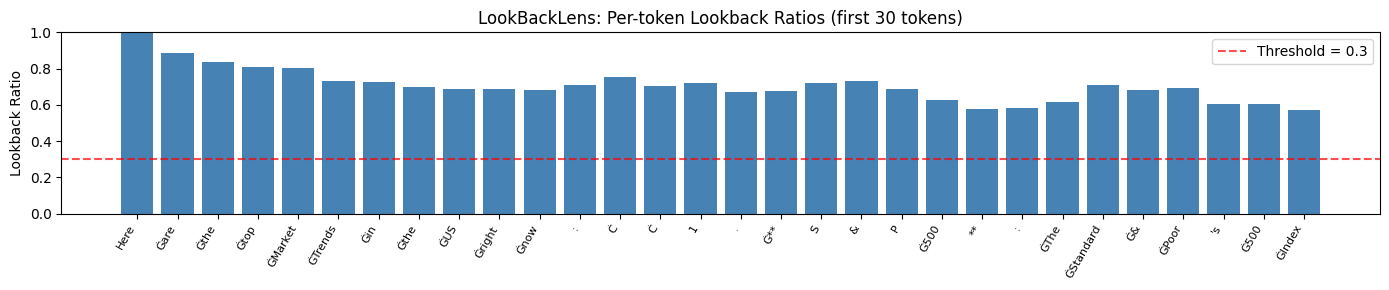

Red bars (ratio < 0.3) = token is mainly attending to prior generated text → potential hallucination signal.


In [ ]:
# Visualise lookback ratios for the first sample
tokens_plot = [r["token"] for r in ratios[:30]]
ratio_vals = [r["lookback_ratio"] for r in ratios[:30]]

fig, ax = plt.subplots(figsize=(14, 3))
colors = ["tomato" if v < 0.3 else "steelblue" for v in ratio_vals]
ax.bar(range(len(tokens_plot)), ratio_vals, color=colors)
ax.axhline(0.3, color="red", linestyle="--", alpha=0.7, label="Threshold = 0.3")
ax.set_xticks(range(len(tokens_plot)))
ax.set_xticklabels(tokens_plot, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Lookback Ratio")
ax.set_title("LookBackLens: Per-token Lookback Ratios (first 30 tokens)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()
print("Red bars (ratio < 0.3) = token is mainly attending to prior generated text → potential hallucination signal.")

#### batch evaluation

In [ ]:
# extract features on train set
lbl_train_feats = []
for _, item in tqdm(train_df.iterrows(), total=len(train_df), desc="LookBackLens train"):
    context_input = f"Question: {item['query']}\nContext: {item['context']}"
    try:
        ratios = compute_lookback_ratios(
            lbl_model, lbl_tokenizer,
            context=context_input,
            answer=item["output"],
        )
        feats = aggregate_lookback_features(ratios)
    except Exception:
        feats = {"mean_ratio": 0.5, "min_ratio": 0.5, "frac_low": 0.0, "std_ratio": 0.0}
    lbl_train_feats.append(feats)

print(f"Train feature extraction complete ({len(lbl_train_feats)} samples).")

# extract features on test set
lbl_raw_results = []
lbl_features = []

for _, item in tqdm(test_df.iterrows(), total=len(test_df), desc="LookBackLens test"):
    context_input = f"Question: {item['query']}\nContext: {item['context']}"
    try:
        ratios = compute_lookback_ratios(
            lbl_model, lbl_tokenizer,
            context=context_input,
            answer=item["output"],
        )
        feats = aggregate_lookback_features(ratios)
    except Exception:
        ratios = []
        feats = {"mean_ratio": 0.5, "min_ratio": 0.5, "frac_low": 0.0, "std_ratio": 0.0}

    lbl_raw_results.append({
        "query": item["query"][:60] + "...",
        "label": item["label"],
        "corruption_type": item["corruption_type"],
        "ratios": ratios,
    })
    lbl_features.append(feats)

print(f"Test feature extraction complete ({len(lbl_features)} samples).")

In [ ]:
# Threshold classifier evaluated against ground-truth labels
THRESHOLD = 0.3

lbl_results = []
for raw, feats in zip(lbl_raw_results, lbl_features):
    mean_r = feats["mean_ratio"]
    lbl_results.append({
        "query": raw["query"],
        "label": raw["label"],
        "corruption_type": raw["corruption_type"],
        "predicted_hallucination_threshold": int(mean_r < THRESHOLD),
        "mean_lookback_ratio": mean_r,
        "min_lookback_ratio": feats["min_ratio"],
        "frac_low_ratio": feats.get("frac_low", feats.get("frac_low_03", 0.0)),
        "std_lookback_ratio": feats["std_ratio"],
    })

df_lbl = pd.DataFrame(lbl_results)
y_true_lbl = df_lbl["label"].values
y_pred_lbl = df_lbl["predicted_hallucination_threshold"].values

print(f"LookBackLens (threshold={THRESHOLD}) on {len(df_lbl)} samples:")
print(f"  Accuracy  : {accuracy_score(y_true_lbl, y_pred_lbl):.3f}")
print(f"  Precision : {precision_score(y_true_lbl, y_pred_lbl, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(y_true_lbl, y_pred_lbl, zero_division=0):.3f}")
print(f"  F1        : {f1_score(y_true_lbl, y_pred_lbl, zero_division=0):.3f}")
print(f"  Mean lookback ratio: {np.mean([r['mean_lookback_ratio'] for r in lbl_results]):.4f}")

LookBackLens (threshold=0.3) on 828 samples:
  Accuracy  : 0.540
  Precision : 0.000
  Recall    : 0.000
  F1        : 0.000
  Mean lookback ratio: 0.6317


In [ ]:
# Logistic Regression: train on train set, evaluate on test set
X_train_lbl = np.array([
    [f["mean_ratio"], f["min_ratio"],
     f.get("frac_low", f.get("frac_low_03", 0.0)),
     f["std_ratio"]]
    for f in lbl_train_feats
])
X_test_lbl = np.array([
    [f["mean_ratio"], f["min_ratio"],
     f.get("frac_low", f.get("frac_low_03", 0.0)),
     f["std_ratio"]]
    for f in lbl_features
])
y_lbl_train = train_df["label"].to_numpy()
y_lbl_test  = test_df["label"].to_numpy()

lbl_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=seed)),
])
lbl_clf.fit(X_train_lbl, y_lbl_train)

y_pred_lr = lbl_clf.predict(X_test_lbl)
lbl_score  = lbl_clf.predict_proba(X_test_lbl)[:, 1]

print(f"LookBackLens LogReg — train={len(X_train_lbl)}, test={len(X_test_lbl)}:")
print(f"  Test Accuracy  : {accuracy_score(y_lbl_test, y_pred_lr):.3f}")
print(f"  Test Precision : {precision_score(y_lbl_test, y_pred_lr, zero_division=0):.3f}")
print(f"  Test Recall    : {recall_score(y_lbl_test, y_pred_lr, zero_division=0):.3f}")
print(f"  Test F1        : {f1_score(y_lbl_test, y_pred_lr, zero_division=0):.3f}")
coef = lbl_clf["clf"].coef_[0]
print(f"  Coefficients   : mean_ratio={coef[0]:.3f}, min_ratio={coef[1]:.3f}, "
      f"frac_low={coef[2]:.3f}, std_ratio={coef[3]:.3f}")

df_lbl["predicted_hallucination_logreg"] = y_pred_lr
df_lbl["lbl_score"] = lbl_score

LookBackLens LogReg — train=3308, test=828:
  Test Accuracy  : 0.506
  Test Precision : 0.476
  Test Recall    : 0.714
  Test F1        : 0.571
  Coefficients   : mean_ratio=-0.256, min_ratio=0.101, frac_low=0.038, std_ratio=-0.092


In [ ]:
print("=== LookBackLens — Metrics by Corruption Type ===")
for ctype, sub in df_lbl.groupby("corruption_type"):
    yt = sub["label"].values
    yp = sub["predicted_hallucination_threshold"].values
    print(
        f"  {ctype:<28} "
        f"acc={accuracy_score(yt, yp):.3f}  "
        f"prec={precision_score(yt, yp, zero_division=0):.3f}  "
        f"rec={recall_score(yt, yp, zero_division=0):.3f}  "
        f"f1={f1_score(yt, yp, zero_division=0):.3f}"
    )

display(df_lbl.head(10))
print("\nValue counts — predicted_hallucination_threshold:")
display(df_lbl["predicted_hallucination_threshold"].value_counts())

=== LookBackLens — Metrics by Corruption Type ===
  clean                        acc=1.000  prec=0.000  rec=0.000  f1=0.000
  missing_tool                 acc=0.580  prec=0.000  rec=0.000  f1=0.000
  overgeneration               acc=0.580  prec=0.000  rec=0.000  f1=0.000
  tool_output_contradiction    acc=0.000  prec=0.000  rec=0.000  f1=0.000


,query,label,corruption_type,predicted_hallucination_threshold,mean_lookback_ratio,min_lookback_ratio,frac_low_ratio,std_lookback_ratio,predicted_hallucination_logreg,lbl_score
0,It's fascinating how languages shape our commu...,0,clean,0,0.594948,0.372283,0.0,0.109732,1,0.500354
1,Could you please provide me with the current t...,0,clean,0,0.599117,0.396825,0.0,0.099062,1,0.522848
2,Given the volatile nature of the crypto market...,0,clean,0,0.584013,0.422570,0.0,0.102467,1,0.543427
3,Could you show me the latest Instagram posts f...,0,clean,0,0.591270,0.423962,0.0,0.109998,1,0.520995
4,"Oh, that's great to know. Now that the serious...",0,clean,0,0.650711,0.455068,0.0,0.110331,0,0.456778
5,Can you please provide the ROA ratio for the c...,0,clean,0,0.664848,0.516321,0.0,0.095435,0,0.486451
6,"Hey, could you get me a list of all the tags i...",0,clean,0,0.674410,0.550597,0.0,0.099940,0,0.477247
7,It's like a jungle out there and I'm just tryi...,0,clean,0,0.541527,0.331777,0.0,0.127297,1,0.520978
8,"Hey, I'm preparing for our next social media c...",0,clean,0,0.573108,0.362262,0.0,0.119285,1,0.506487
9,Could you provide me with the top players' sta...,0,clean,0,0.547655,0.363817,0.0,0.117828,1,0.541157



Value counts — predicted_hallucination_threshold:


,count
predicted_hallucination_threshold,
0,828


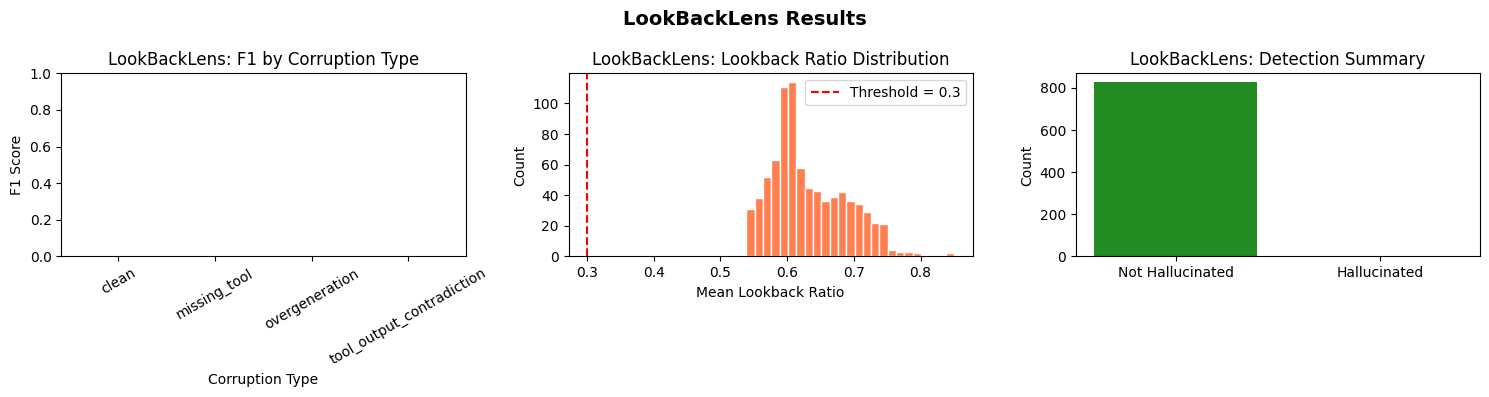

In [ ]:
lbl_types = sorted(df_lbl["corruption_type"].unique())
f1_by_type_lbl = {
    ct: f1_score(
        df_lbl[df_lbl["corruption_type"] == ct]["label"],
        df_lbl[df_lbl["corruption_type"] == ct]["predicted_hallucination_threshold"],
        zero_division=0,
    )
    for ct in lbl_types
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(f1_by_type_lbl.keys(), f1_by_type_lbl.values(), color="coral")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Corruption Type")
axes[0].set_ylabel("F1 Score")
axes[0].set_title("LookBackLens: F1 by Corruption Type")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(df_lbl["mean_lookback_ratio"], bins=25, color="coral", edgecolor="white")
axes[1].axvline(THRESHOLD, color="red", linestyle="--", label=f"Threshold = {THRESHOLD}")
axes[1].set_xlabel("Mean Lookback Ratio")
axes[1].set_ylabel("Count")
axes[1].set_title("LookBackLens: Lookback Ratio Distribution")
axes[1].legend()

counts_lbl = df_lbl["predicted_hallucination_threshold"].value_counts()
axes[2].bar(
    ["Not Hallucinated", "Hallucinated"],
    [counts_lbl.get(0, 0), counts_lbl.get(1, 0)],
    color=["forestgreen", "tomato"],
)
axes[2].set_ylabel("Count")
axes[2].set_title("LookBackLens: Detection Summary")

plt.suptitle("LookBackLens Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Side by side comparison
Both methods are evaluated on the same shared `eval_df` benchmark (clean + 3 corruption types)
using ground-truth `hallucination_labels`.  Metrics reported: Accuracy, Precision, Recall, F1.

Corruption types:
- **tool_output_contradiction** — output contradicts the tool's returned data
- **overgeneration** — model adds facts not present in the tool output
- **missing_tool** — model claims to use a tool that was never called

In [ ]:
# Both df_lettuce and df_lbl are evaluated on the same test_df rows (same order)
comparison = pd.DataFrame({
    "query":                   df_lettuce["query"].values,
    "label":                   df_lettuce["label"].values,
    "corruption_type":         df_lettuce["corruption_type"].values,
    "LettuceDetect_flag":      df_lettuce["predicted_hallucination"].values,
    "LettuceDetect_score":     df_lettuce["lettuce_score"].values,
    "LookBackLens_flag":       df_lbl["predicted_hallucination_logreg"].values,
    "LookBackLens_score":      df_lbl["lbl_score"].values,
    "LookBackLens_mean_ratio": df_lbl["mean_lookback_ratio"].values,
})

y_true_c = comparison["label"].values
for method, col in [("LettuceDetect (LogReg)", "LettuceDetect_flag"),
                    ("LookBackLens  (LogReg)", "LookBackLens_flag")]:
    yp = comparison[col].values
    n  = len(comparison)
    print(f"\n{method} (n={n}):")
    print(f"  Accuracy  : {accuracy_score(y_true_c, yp):.3f}")
    print(f"  Precision : {precision_score(y_true_c, yp, zero_division=0):.3f}")
    print(f"  Recall    : {recall_score(y_true_c, yp, zero_division=0):.3f}")
    print(f"  F1        : {f1_score(y_true_c, yp, zero_division=0):.3f}")

n_eval     = len(comparison)
both_flag  = ((comparison["LettuceDetect_flag"] == 1) & (comparison["LookBackLens_flag"] == 1)).sum()
either_flag = ((comparison["LettuceDetect_flag"] == 1) | (comparison["LookBackLens_flag"] == 1)).sum()
agree_no   = ((comparison["LettuceDetect_flag"] == 0) & (comparison["LookBackLens_flag"] == 0)).sum()
print(f"\n=== Agreement Statistics (n={n_eval}) ===")
print(f"Both methods flag hallucination : {both_flag} ({both_flag / n_eval:.1%})")
print(f"At least one method flags        : {either_flag} ({either_flag / n_eval:.1%})")
print(f"Both agree: NOT hallucinated     : {agree_no} ({agree_no / n_eval:.1%})")

display(comparison.head(15))


LettuceDetect (LogReg) (n=828):
  Accuracy  : 0.460
  Precision : 0.460
  Recall    : 1.000
  F1        : 0.630

LookBackLens  (LogReg) (n=828):
  Accuracy  : 0.506
  Precision : 0.476
  Recall    : 0.714
  F1        : 0.571

=== Agreement Statistics (n=828) ===
Both methods flag hallucination : 572 (69.1%)
At least one method flags        : 828 (100.0%)
Both agree: NOT hallucinated     : 0 (0.0%)


,query,label,corruption_type,LettuceDetect_flag,LettuceDetect_score,LookBackLens_flag,LookBackLens_score,LookBackLens_mean_ratio
0,It's fascinating how languages shape our commu...,0,clean,1,0.511185,1,0.500354,0.594948
1,Could you please provide me with the current t...,0,clean,1,0.511185,1,0.522848,0.599117
2,Given the volatile nature of the crypto market...,0,clean,1,0.511185,1,0.543427,0.584013
3,Could you show me the latest Instagram posts f...,0,clean,1,0.511185,1,0.520995,0.591270
4,"Oh, that's great to know. Now that the serious...",0,clean,1,0.511185,0,0.456778,0.650711
5,Can you please provide the ROA ratio for the c...,0,clean,1,0.511185,0,0.486451,0.664848
6,"Hey, could you get me a list of all the tags i...",0,clean,1,0.511185,0,0.477247,0.674410
7,It's like a jungle out there and I'm just tryi...,0,clean,1,0.511185,1,0.520978,0.541527
8,"Hey, I'm preparing for our next social media c...",0,clean,1,0.511185,1,0.506487,0.573108
9,Could you provide me with the top players' sta...,0,clean,1,0.511185,1,0.541157,0.547655


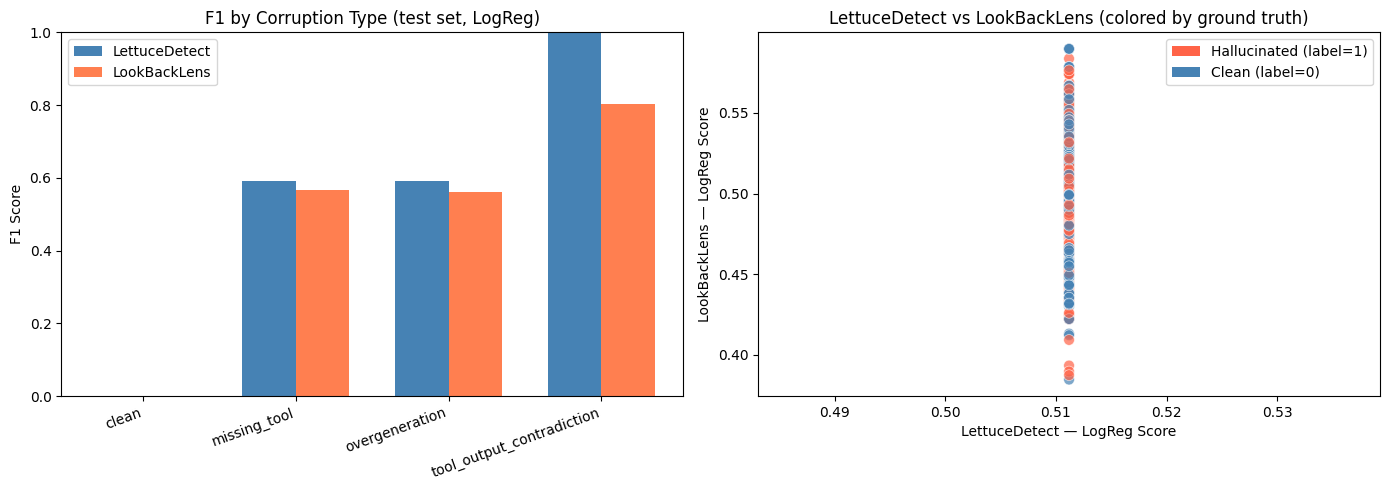

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar: F1 by corruption type for both methods
all_types = sorted(comparison["corruption_type"].unique())
lettuce_f1s, lbl_f1s = [], []
for ct in all_types:
    sub = comparison[comparison["corruption_type"] == ct]
    lettuce_f1s.append(f1_score(sub["label"], sub["LettuceDetect_flag"], zero_division=0))
    lbl_f1s.append(f1_score(sub["label"], sub["LookBackLens_flag"], zero_division=0))

x = np.arange(len(all_types))
w = 0.35
axes[0].bar(x - w / 2, lettuce_f1s, w, label="LettuceDetect", color="steelblue")
axes[0].bar(x + w / 2, lbl_f1s,     w, label="LookBackLens",  color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_types, rotation=20, ha="right")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("F1 Score")
axes[0].set_title("F1 by Corruption Type (test set, LogReg)")
axes[0].legend()

# Scatter: LogReg scores for both methods, colored by ground-truth label
colors = ["tomato" if lb == 1 else "steelblue" for lb in comparison["label"]]
axes[1].scatter(
    comparison["LettuceDetect_score"],
    comparison["LookBackLens_score"],
    c=colors, alpha=0.7, edgecolors="white", linewidths=0.5, s=60,
)
axes[1].set_xlabel("LettuceDetect — LogReg Score")
axes[1].set_ylabel("LookBackLens — LogReg Score")
axes[1].set_title("LettuceDetect vs LookBackLens (colored by ground truth)")

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor="tomato",    label="Hallucinated (label=1)"),
    Patch(facecolor="steelblue", label="Clean (label=0)"),
])

plt.tight_layout()
plt.show()

In [ ]:
y_true_s = comparison["label"].values

summary = pd.DataFrame({
    "Method":    ["LettuceDetect", "LookBackLens"],
    "Classifier": ["LogisticRegression (train/test split)",
                   "LogisticRegression (train/test split)"],
    "Backbone":  [
        "ModernBERT (lettucedect-base-modernbert-en-v1)",
        "GPT-2 (demo; paper uses Llama-2-7B)",
    ],
    "Train Samples": [len(train_df), len(train_df)],
    "Test Samples":  [len(test_df),  len(test_df)],
    "Accuracy": [
        f"{accuracy_score(y_true_s, comparison['LettuceDetect_flag'].values):.3f}",
        f"{accuracy_score(y_true_s, comparison['LookBackLens_flag'].values):.3f}",
    ],
    "Precision": [
        f"{precision_score(y_true_s, comparison['LettuceDetect_flag'].values, zero_division=0):.3f}",
        f"{precision_score(y_true_s, comparison['LookBackLens_flag'].values, zero_division=0):.3f}",
    ],
    "Recall": [
        f"{recall_score(y_true_s, comparison['LettuceDetect_flag'].values, zero_division=0):.3f}",
        f"{recall_score(y_true_s, comparison['LookBackLens_flag'].values, zero_division=0):.3f}",
    ],
    "F1": [
        f"{f1_score(y_true_s, comparison['LettuceDetect_flag'].values, zero_division=0):.3f}",
        f"{f1_score(y_true_s, comparison['LookBackLens_flag'].values, zero_division=0):.3f}",
    ],
})
display(summary)

print(f'''
Split: train_test_split(example_ids, test_size=0.2, random_state={seed})
  Train: {len(train_df)} rows  |  Test: {len(test_df)} rows  |  No example_id leakage

CORRUPTION_FILES from datasets/:
  tool_output_contradiction  - output contradicts the tool's returned data
  overgeneration             - model adds facts not present in the tool output
  missing_tool               - model claims to use a tool that was never called

Classifiers (both): Pipeline([StandardScaler, LogisticRegression(max_iter=1000)])
  LettuceDetect features : max span score, number of hallucinated spans
  LookBackLens features  : mean_ratio, min_ratio, frac_low, std_ratio
''')

,Method,Classifier,Backbone,Train Samples,Test Samples,Accuracy,Precision,Recall,F1
0,LettuceDetect,LogisticRegression (train/test split),ModernBERT (lettucedect-base-modernbert-en-v1),3308,828,0.460,0.460,1.000,0.630
1,LookBackLens,LogisticRegression (train/test split),GPT-2 (demo; paper uses Llama-2-7B),3308,828,0.506,0.476,0.714,0.571



Split: train_test_split(example_ids, test_size=0.2, random_state=1241)
  Train: 3308 rows  |  Test: 828 rows  |  No example_id leakage

CORRUPTION_FILES from datasets/:
  tool_output_contradiction  - output contradicts the tool's returned data
  overgeneration             - model adds facts not present in the tool output
  missing_tool               - model claims to use a tool that was never called

Classifiers (both): Pipeline([StandardScaler, LogisticRegression(max_iter=1000)])
  LettuceDetect features : max span score, number of hallucinated spans
  LookBackLens features  : mean_ratio, min_ratio, frac_low, std_ratio



## 4. Grouped train/test split without leakage

Every original ToolACE sample produces four rows in the benchmark:
- one clean example
- one contradiction example
- one overgeneration example
- one missing-tool example

To avoid leakage, we split by `example_id`, not by row.


In [ ]:
all_example_ids = sorted(benchmark_df["example_id"].unique())
train_ids, test_ids = train_test_split(all_example_ids, test_size=0.2, random_state=seed)

train_df = benchmark_df[benchmark_df["example_id"].isin(train_ids)].reset_index(drop=True)
test_df = benchmark_df[benchmark_df["example_id"].isin(test_ids)].reset_index(drop=True)

print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")
print(f"Overlap in example_id: {len(set(train_ids) & set(test_ids))}")

display(train_df.groupby(["corruption_type", "label"]).size().rename("train_count").reset_index())
display(test_df.groupby(["corruption_type", "label"]).size().rename("test_count").reset_index())


Train rows: 3308
Test rows:  828
Overlap in example_id: 0


,corruption_type,label,train_count
0,clean,0,827
1,missing_tool,0,395
2,missing_tool,1,432
3,overgeneration,0,395
4,overgeneration,1,432
5,tool_output_contradiction,1,827


,corruption_type,label,test_count
0,clean,0,207
1,missing_tool,0,120
2,missing_tool,1,87
3,overgeneration,0,120
4,overgeneration,1,87
5,tool_output_contradiction,1,207


## 5. Evaluation helpers


In [ ]:
def evaluate_predictions(y_true, y_pred, y_score=None, prefix="model"):
    metrics = {
        "model": prefix,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    metrics["precision"] = p
    metrics["recall"] = r
    metrics["f1_binary"] = f1

    if y_score is not None and len(np.unique(y_true)) > 1:
        metrics["auroc"] = roc_auc_score(y_true, y_score)
        metrics["ap"] = average_precision_score(y_true, y_score)
    else:
        metrics["auroc"] = np.nan
        metrics["ap"] = np.nan

    return metrics


def evaluate_by_type(df, pred_col, score_col=None, span_col=None):
    rows = []
    for corruption_type, sub in df.groupby("corruption_type"):
        y_true = sub["label"].to_numpy()
        y_pred = sub[pred_col].to_numpy()
        y_score = sub[score_col].to_numpy() if score_col and score_col in sub.columns else None
        metrics = evaluate_predictions(y_true, y_pred, y_score=y_score, prefix=corruption_type)
        if span_col is not None:
            metrics.update(build_span_eval_frame(sub, span_col))
        rows.append(metrics)
    return pd.DataFrame(rows)


def build_method_report(df, pred_col, score_col, span_col, model_name):
    overall = evaluate_predictions(
        df["label"].to_numpy(),
        df[pred_col].to_numpy(),
        df[score_col].to_numpy() if score_col else None,
        prefix=model_name,
    )
    if span_col is not None:
        overall.update(build_span_eval_frame(df, span_col))
    overall_df = pd.DataFrame([overall])
    by_type_df = evaluate_by_type(df, pred_col=pred_col, score_col=score_col, span_col=span_col)
    return overall_df, by_type_df


def max_span_score(spans):
    return max((float(span.get("score", 0.0)) for span in spans), default=0.0)


## 3.3 Improve Baselines

### Baseline A: tool-aware lexical span detector

This baseline now works at span level:
- normalize the raw tool JSON into readable factual context
- find unsupported facts directly in the answer
- convert them into predicted hallucination spans
- derive sample-level predictions from span presence


In [ ]:
def run_lexical_span_detector(row):
    spans = lexical_hallucination_spans(row)
    feats = aggregate_span_features(spans, len(row["output"]))
    return spans, feats


In [ ]:
lex_train_rows = train_df.copy()
lex_test_rows = test_df.copy()

lex_train_spans = []
lex_train_feats = []
for _, row in tqdm(lex_train_rows.iterrows(), total=len(lex_train_rows), desc="Lexical train"):
    spans, feats = run_lexical_span_detector(row)
    lex_train_spans.append(spans)
    lex_train_feats.append(feats)

lex_test_spans = []
lex_test_feats = []
for _, row in tqdm(lex_test_rows.iterrows(), total=len(lex_test_rows), desc="Lexical test"):
    spans, feats = run_lexical_span_detector(row)
    lex_test_spans.append(spans)
    lex_test_feats.append(feats)

lex_train_X = pd.DataFrame(lex_train_feats)
lex_test_X = pd.DataFrame(lex_test_feats)
y_train = lex_train_rows["label"].to_numpy()
y_test = lex_test_rows["label"].to_numpy()

lex_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=seed)),
])
lex_clf.fit(lex_train_X, y_train)

lex_test_pred = lex_clf.predict(lex_test_X)
lex_test_score = lex_clf.predict_proba(lex_test_X)[:, 1]

test_df_lex = lex_test_rows.copy()
test_df_lex["lexical_spans"] = lex_test_spans
test_df_lex["lex_pred"] = lex_test_pred
test_df_lex["lex_score"] = lex_test_score
test_df_lex["lex_direct_pred"] = test_df_lex["lexical_spans"].apply(lambda spans: int(len(spans) > 0))
test_df_lex["lex_direct_score"] = test_df_lex["lexical_spans"].apply(max_span_score)

lex_overall, lex_by_type = build_method_report(
    test_df_lex,
    pred_col="lex_pred",
    score_col="lex_score",
    span_col="lexical_spans",
    model_name="lexical_span_verifier",
)

display(lex_overall)
display(lex_by_type)


Lexical train:   0%|          | 0/3308 [00:00<?, ?it/s]

Lexical test:   0%|          | 0/828 [00:00<?, ?it/s]

,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,lexical_span_verifier,0.566425,0.52324,0.52957,0.51706,0.52324,0.602506,0.554994,0.037615,0.088668,0.052821,0.036232


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,clean,0.618357,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.072464
1,missing_tool,0.589372,0.540541,0.510204,0.574713,0.540541,0.634962,0.554159,0.080189,0.095204,0.087054,0.014493
2,overgeneration,0.550725,0.474576,0.466667,0.482759,0.474576,0.581657,0.507871,0.069383,0.082079,0.075199,0.014493
3,tool_output_contradiction,0.507246,0.673077,1.000000,0.507246,0.673077,NaN,NaN,0.000000,0.000000,0.000000,0.043478


### Baseline B: improved LettuceDetect for span-level detection

LettuceDetect already predicts spans, so we keep its native span output,
normalize it to our format, then train a small sample-level classifier on
top of span features for comparison.


In [ ]:
from lettucedetect.models.inference import HallucinationDetector

MODEL_PATH = "KRLabsOrg/lettucedect-base-modernbert-en-v1"
print(f"Loading LettuceDetect model: {MODEL_PATH}")
lettuce_detector = HallucinationDetector(method="transformer", model_path=MODEL_PATH)
print("Model loaded.")


Loading LettuceDetect model: KRLabsOrg/lettucedect-base-modernbert-en-v1


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Model loaded.


In [ ]:
def run_lettuce(row, context_col="normalized_context"):
    raw_spans = lettuce_detector.predict(
        context=[row[context_col]],
        question=row["query"],
        answer=row["output"],
        output_format="spans",
    )

    spans = []
    for span in raw_spans:
        start = int(span.get("start", 0))
        end = int(span.get("end", 0))
        if end <= start:
            continue
        spans.append({
            "start": start,
            "end": end,
            "text": row["output"][start:end],
            "type": "hallucination",
            "score": float(span.get("score", 0.0)),
        })

    spans = merge_spans(spans)
    feats = aggregate_span_features(spans, len(row["output"]))
    return spans, feats


In [ ]:
LETTUCE_TRAIN_LIMIT = None
LETTUCE_TEST_LIMIT = None

lettuce_train_rows = train_df if LETTUCE_TRAIN_LIMIT is None else train_df.iloc[:LETTUCE_TRAIN_LIMIT]
lettuce_test_rows = test_df if LETTUCE_TEST_LIMIT is None else test_df.iloc[:LETTUCE_TEST_LIMIT]

lettuce_train_spans = []
lettuce_train_feats = []
for _, row in tqdm(lettuce_train_rows.iterrows(), total=len(lettuce_train_rows), desc="Lettuce train"):
    try:
        spans, feats = run_lettuce(row)
    except Exception as exc:
        spans = []
        feats = {**aggregate_span_features([], len(row["output"])), "error": str(exc)}
    lettuce_train_spans.append(spans)
    lettuce_train_feats.append(feats)

lettuce_test_spans = []
lettuce_test_feats = []
for _, row in tqdm(lettuce_test_rows.iterrows(), total=len(lettuce_test_rows), desc="Lettuce test"):
    try:
        spans, feats = run_lettuce(row)
    except Exception as exc:
        spans = []
        feats = {**aggregate_span_features([], len(row["output"])), "error": str(exc)}
    lettuce_test_spans.append(spans)
    lettuce_test_feats.append(feats)

lettuce_train_X = pd.DataFrame(lettuce_train_feats).drop(columns=["error"], errors="ignore")
lettuce_test_X = pd.DataFrame(lettuce_test_feats).drop(columns=["error"], errors="ignore")
lettuce_y_train = lettuce_train_rows["label"].to_numpy()
lettuce_y_test = lettuce_test_rows["label"].to_numpy()

lettuce_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=seed)),
])
lettuce_clf.fit(lettuce_train_X, lettuce_y_train)

lettuce_test_pred = lettuce_clf.predict(lettuce_test_X)
lettuce_test_score = lettuce_clf.predict_proba(lettuce_test_X)[:, 1]

test_df_lettuce = lettuce_test_rows.copy()
test_df_lettuce["lettuce_spans"] = lettuce_test_spans
test_df_lettuce["lettuce_pred"] = lettuce_test_pred
test_df_lettuce["lettuce_score"] = lettuce_test_score
test_df_lettuce["lettuce_direct_pred"] = test_df_lettuce["lettuce_spans"].apply(lambda spans: int(len(spans) > 0))
test_df_lettuce["lettuce_direct_score"] = test_df_lettuce["lettuce_spans"].apply(max_span_score)

lettuce_overall, lettuce_by_type = build_method_report(
    test_df_lettuce,
    pred_col="lettuce_pred",
    score_col="lettuce_score",
    span_col="lettuce_spans",
    model_name="lettuce_span_supervised",
)

display(lettuce_overall)
display(lettuce_by_type)


Lettuce train:   0%|          | 0/3308 [00:00<?, ?it/s]

Lettuce test:   0%|          | 0/828 [00:00<?, ?it/s]

,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,lettuce_span_supervised,0.677536,0.631724,0.665698,0.60105,0.631724,0.721424,0.639676,0.123713,0.660035,0.20837,0.320048


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,clean,0.782609,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.536232
1,missing_tool,0.632850,0.547619,0.567901,0.528736,0.547619,0.650958,0.524429,0.173808,0.445003,0.249980,0.280193
2,overgeneration,0.714976,0.681081,0.642857,0.724138,0.681081,0.782375,0.644869,0.285506,0.876809,0.430751,0.280193
3,tool_output_contradiction,0.579710,0.733945,1.000000,0.579710,0.733945,NaN,NaN,0.000000,0.000000,0.000000,0.183575


### Baseline C: stronger LookBack-style span detector

Changes from the previous version:
- use normalized factual context instead of raw JSON blobs
- replace `gpt2` with `Qwen/Qwen2.5-0.5B`
- keep token-level lookback ratios with offsets
- convert low-grounding tokens into predicted hallucination spans
- train a sample-level classifier on top of ratio and span features


In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    if torch.cuda.is_bf16_supported():
        MODEL_DTYPE = torch.bfloat16
    else:
        MODEL_DTYPE = torch.float16
else:
    MODEL_DTYPE = torch.float32

print(f"Loading LookBackLens backbone: {MODEL_NAME} on {DEVICE} with dtype={MODEL_DTYPE}")
lbl_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
lbl_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
    attn_implementation="eager",
).to(DEVICE)
lbl_model.eval()

if lbl_tokenizer.pad_token is None:
    lbl_tokenizer.pad_token = lbl_tokenizer.eos_token

print("Model loaded.")
print(DEVICE)


Loading LookBackLens backbone: Qwen/Qwen2.5-0.5B on cuda with dtype=torch.bfloat16


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Model loaded.
cuda


In [ ]:
def compute_lookback_ratios(model, tokenizer, context, answer, max_context_tokens=384, max_answer_tokens=160):
    ctx_enc = tokenizer(
        context,
        add_special_tokens=True,
        truncation=True,
        max_length=max_context_tokens,
    )
    ans_enc = tokenizer(
        answer,
        add_special_tokens=False,
        truncation=True,
        max_length=max_answer_tokens,
        return_offsets_mapping=True,
    )

    ctx_ids = ctx_enc["input_ids"]
    ans_ids = ans_enc["input_ids"]
    offsets = ans_enc["offset_mapping"]

    if not ans_ids:
        return []

    context_len = len(ctx_ids)
    full_ids = ctx_ids + ans_ids
    input_ids = torch.tensor([full_ids], dtype=torch.long).to(model.device)

    with torch.no_grad():
        outputs = model(input_ids, output_attentions=True)

    n_layers = len(outputs.attentions)
    avg_attn = outputs.attentions[0][0].mean(0)
    for layer_attn in outputs.attentions[1:]:
        avg_attn = avg_attn + layer_attn[0].mean(0)
    avg_attn = (avg_attn / n_layers).float().cpu()

    answer_tokens = tokenizer.convert_ids_to_tokens(ans_ids)
    ratios = []
    total_len = len(full_ids)

    for offset_idx, t in enumerate(range(context_len, total_len)):
        row = avg_attn[t, : t + 1]
        attn_ctx = row[:context_len].sum().item()
        attn_gen = row[context_len:t].sum().item()
        denom = attn_ctx + attn_gen
        ratio = (attn_ctx / denom) if denom > 1e-9 else 0.5
        start, end = offsets[offset_idx]
        token_str = answer_tokens[offset_idx] if offset_idx < len(answer_tokens) else "<unk>"
        ratios.append({
            "token": token_str,
            "start": int(start),
            "end": int(end),
            "lookback_ratio": ratio,
            "attn_to_context": attn_ctx,
            "attn_to_generated": attn_gen,
        })

    del outputs
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return ratios


In [ ]:
LBL_TRAIN_LIMIT = None
LBL_TEST_LIMIT = None

lbl_train_rows = train_df if LBL_TRAIN_LIMIT is None else train_df.iloc[:LBL_TRAIN_LIMIT]
lbl_test_rows = test_df if LBL_TEST_LIMIT is None else test_df.iloc[:LBL_TEST_LIMIT]

lbl_train_feats = []
lbl_train_spans = []
for _, row in tqdm(lbl_train_rows.iterrows(), total=len(lbl_train_rows), desc="LookBack train"):
    context_input = f"Question: {row['query']}\nContext: {row['normalized_context']}"
    try:
        ratios = compute_lookback_ratios(lbl_model, lbl_tokenizer, context=context_input, answer=row["output"])
        spans = spans_from_lookback_ratios(row["output"], ratios, low_threshold=0.22)
        feats = aggregate_lookback_features(ratios)
        feats.update(aggregate_span_features(spans, len(row["output"])))
    except Exception as exc:
        ratios = []
        spans = []
        feats = {
            **aggregate_lookback_features([]),
            **aggregate_span_features([], len(row["output"])),
            "error": str(exc),
        }
    lbl_train_spans.append(spans)
    lbl_train_feats.append(feats)

lbl_test_feats = []
lbl_test_spans = []
for _, row in tqdm(lbl_test_rows.iterrows(), total=len(lbl_test_rows), desc="LookBack test"):
    context_input = f"Question: {row['query']}\nContext: {row['normalized_context']}"
    try:
        ratios = compute_lookback_ratios(lbl_model, lbl_tokenizer, context=context_input, answer=row["output"])
        spans = spans_from_lookback_ratios(row["output"], ratios, low_threshold=0.22)
        feats = aggregate_lookback_features(ratios)
        feats.update(aggregate_span_features(spans, len(row["output"])))
    except Exception as exc:
        ratios = []
        spans = []
        feats = {
            **aggregate_lookback_features([]),
            **aggregate_span_features([], len(row["output"])),
            "error": str(exc),
        }
    lbl_test_spans.append(spans)
    lbl_test_feats.append(feats)

lbl_train_X = pd.DataFrame(lbl_train_feats).drop(columns=["error"], errors="ignore")
lbl_test_X = pd.DataFrame(lbl_test_feats).drop(columns=["error"], errors="ignore")
lbl_y_train = lbl_train_rows["label"].to_numpy()
lbl_y_test = lbl_test_rows["label"].to_numpy()

lbl_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=seed)),
])
lbl_clf.fit(lbl_train_X, lbl_y_train)

lbl_test_pred = lbl_clf.predict(lbl_test_X)
lbl_test_score = lbl_clf.predict_proba(lbl_test_X)[:, 1]

test_df_lbl = lbl_test_rows.copy()
test_df_lbl["lbl_spans"] = lbl_test_spans
test_df_lbl["lbl_pred"] = lbl_test_pred
test_df_lbl["lbl_score"] = lbl_test_score
test_df_lbl["lbl_direct_pred"] = test_df_lbl["lbl_spans"].apply(lambda spans: int(len(spans) > 0))
test_df_lbl["lbl_direct_score"] = test_df_lbl["lbl_spans"].apply(max_span_score)

lbl_overall, lbl_by_type = build_method_report(
    test_df_lbl,
    pred_col="lbl_pred",
    score_col="lbl_score",
    span_col="lbl_spans",
    model_name="lookback_span_supervised",
)

display(lbl_overall)
display(lbl_by_type)


LookBack train:   0%|          | 0/3308 [00:00<?, ?it/s]

LookBack test:   0%|          | 0/828 [00:00<?, ?it/s]

,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,lookback_span_supervised,0.48913,0.560748,0.463918,0.708661,0.560748,0.510681,0.465835,0.0,0.0,0.0,0.789855


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,clean,0.294686,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,0.0,1.00000
1,missing_tool,0.512077,0.577406,0.453947,0.793103,0.577406,0.587261,0.508496,0.0,0.0,0.0,0.57971
2,overgeneration,0.492754,0.553191,0.439189,0.747126,0.553191,0.559579,0.487233,0.0,0.0,0.0,0.57971
3,tool_output_contradiction,0.657005,0.793003,1.000000,0.657005,0.793003,NaN,NaN,0.0,0.0,0.0,1.00000


## 9. Soft-voting ensemble

A simple ensemble often works better than any individual detector.
We average the available sample-level probabilities.


In [ ]:
if len(lettuce_test_rows) != len(test_df) or len(lbl_test_rows) != len(test_df):
    raise ValueError("Set LETTUCE_TEST_LIMIT and LBL_TEST_LIMIT to None for the ensemble, or align the subsets manually.")

ensemble_df = test_df.copy().reset_index(drop=True)
ensemble_df["lex_score"] = lex_test_score
ensemble_df["lettuce_score"] = lettuce_test_score
ensemble_df["lbl_score"] = lbl_test_score

ensemble_df["ensemble_score"] = ensemble_df[["lex_score", "lettuce_score", "lbl_score"]].mean(axis=1)
ensemble_df["ensemble_pred"] = (ensemble_df["ensemble_score"] >= 0.5).astype(int)

# For span-level evaluation we union the spans from the three detectors.
ensemble_spans = []
for lex_spans, lettuce_spans, lbl_spans in zip(
    test_df_lex["lexical_spans"],
    test_df_lettuce["lettuce_spans"],
    test_df_lbl["lbl_spans"],
):
    ensemble_spans.append(merge_spans(list(lex_spans) + list(lettuce_spans) + list(lbl_spans)))
ensemble_df["ensemble_spans"] = ensemble_spans

ensemble_overall, ensemble_by_type = build_method_report(
    ensemble_df,
    pred_col="ensemble_pred",
    score_col="ensemble_score",
    span_col="ensemble_spans",
    model_name="soft_vote_ensemble",
)

display(ensemble_overall)
display(ensemble_by_type)


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,soft_vote_ensemble,0.676329,0.659033,0.639506,0.67979,0.659033,0.721115,0.661023,0.102939,0.69096,0.179184,0.02657


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,clean,0.710145,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.062802
1,missing_tool,0.652174,0.617021,0.574257,0.666667,0.617021,0.688123,0.606927,0.150909,0.499426,0.231782,0.014493
2,overgeneration,0.705314,0.693467,0.616071,0.793103,0.693467,0.777395,0.675067,0.234245,0.884047,0.370357,0.014493
3,tool_output_contradiction,0.637681,0.778761,1.000000,0.637681,0.778761,NaN,NaN,0.000000,0.000000,0.000000,0.014493


## 10. Compare all methods


In [ ]:
summary = pd.concat([
    lex_overall,
    lettuce_overall,
    lbl_overall,
    ensemble_overall,
], ignore_index=True)

display(summary.sort_values(["span_f1", "f1"], ascending=False))


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
1,lettuce_span_supervised,0.677536,0.631724,0.665698,0.601050,0.631724,0.721424,0.639676,0.123713,0.660035,0.208370,0.320048
3,soft_vote_ensemble,0.676329,0.659033,0.639506,0.679790,0.659033,0.721115,0.661023,0.102939,0.690960,0.179184,0.026570
0,lexical_span_verifier,0.566425,0.523240,0.529570,0.517060,0.523240,0.602506,0.554994,0.037615,0.088668,0.052821,0.036232
2,lookback_span_supervised,0.489130,0.560748,0.463918,0.708661,0.560748,0.510681,0.465835,0.000000,0.000000,0.000000,0.789855


In [ ]:
by_type_summary = pd.concat([
    lex_by_type.assign(method="lexical_span_verifier"),
    lettuce_by_type.assign(method="lettuce_span_supervised"),
    lbl_by_type.assign(method="lookback_span_supervised"),
    ensemble_by_type.assign(method="soft_vote_ensemble"),
], ignore_index=True)

display(by_type_summary.sort_values(["model", "span_f1", "f1"], ascending=[True, False, False]))


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate,method
0,clean,0.618357,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.072464,lexical_span_verifier
4,clean,0.782609,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.536232,lettuce_span_supervised
8,clean,0.294686,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,1.000000,lookback_span_supervised
12,clean,0.710145,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.062802,soft_vote_ensemble
5,missing_tool,0.632850,0.547619,0.567901,0.528736,0.547619,0.650958,0.524429,0.173808,0.445003,0.249980,0.280193,lettuce_span_supervised
13,missing_tool,0.652174,0.617021,0.574257,0.666667,0.617021,0.688123,0.606927,0.150909,0.499426,0.231782,0.014493,soft_vote_ensemble
1,missing_tool,0.589372,0.540541,0.510204,0.574713,0.540541,0.634962,0.554159,0.080189,0.095204,0.087054,0.014493,lexical_span_verifier
9,missing_tool,0.512077,0.577406,0.453947,0.793103,0.577406,0.587261,0.508496,0.000000,0.000000,0.000000,0.579710,lookback_span_supervised
6,overgeneration,0.714976,0.681081,0.642857,0.724138,0.681081,0.782375,0.644869,0.285506,0.876809,0.430751,0.280193,lettuce_span_supervised
14,overgeneration,0.705314,0.693467,0.616071,0.793103,0.693467,0.777395,0.675067,0.234245,0.884047,0.370357,0.014493,soft_vote_ensemble


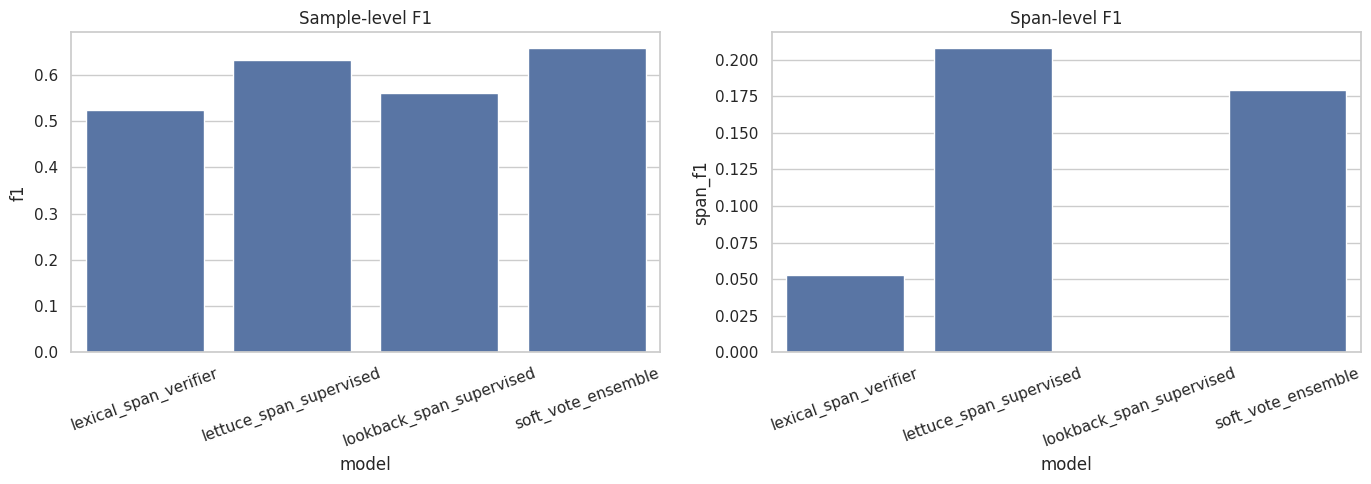

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x="model", y="f1", ax=axes[0])
axes[0].set_title("Sample-level F1")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=summary, x="model", y="span_f1", ax=axes[1])
axes[1].set_title("Span-level F1")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 11. Error analysis helper


In [ ]:
def show_errors(df, score_col, pred_col, span_col, only_type=None, n=10):
    sub = df.copy()
    if only_type is not None:
        sub = sub[sub["corruption_type"] == only_type]

    mistakes = sub[sub["label"] != sub[pred_col]].copy()
    mistakes = mistakes.sort_values(score_col, ascending=False).head(n)

    cols = ["corruption_type", "label", pred_col, score_col, "query", "output", span_col]
    return mistakes[cols]

show_errors(ensemble_df, score_col="ensemble_score", pred_col="ensemble_pred", span_col="ensemble_spans", n=5)


,corruption_type,label,ensemble_pred,ensemble_score,query,output,ensemble_spans
108,clean,0,1,0.673630,Could you let me know what languages are suppo...,The supported languages for text analysis task...,"[{'start': 28, 'end': 32, 'text': 'text', 'typ..."
17,clean,0,1,0.652265,What kind of stats are usually tracked for NBA...,It seems there was no specific data returned f...,"[{'start': 87, 'end': 94, 'text': 'However', '..."
548,overgeneration,0,1,0.629697,Could you please provide the date when the Ear...,The date when Earth was closest to the sun in ...,"[{'start': 0, 'end': 67, 'text': 'The date whe..."
755,missing_tool,0,1,0.629697,Could you please provide the date when the Ear...,The date when Earth was closest to the sun in ...,"[{'start': 0, 'end': 67, 'text': 'The date whe..."
718,missing_tool,0,1,0.624329,"Hey, I'm curious! Do you happen to know how ma...","Based on the data returned, it can be stated t...","[{'start': 0, 'end': 5, 'text': 'Based', 'type..."


In [ ]:
from pathlib import Path
import json
import pandas as pd

export_dir = Path("analysis_exports")
export_dir.mkdir(exist_ok=True)

# 1. Summary tables
summary.to_csv(export_dir / "summary_metrics.csv", index=False)
by_type_summary.to_csv(export_dir / "by_type_metrics.csv", index=False)

# 2. Full prediction tables
def _serialize_df(df, span_cols):
    df = df.copy()
    for col in span_cols:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: json.dumps(x, ensure_ascii=False))
    if "hallucination_labels" in df.columns:
        df["hallucination_labels"] = df["hallucination_labels"].apply(
            lambda x: json.dumps(x, ensure_ascii=False)
        )
    if "meta" in df.columns:
        df["meta"] = df["meta"].apply(lambda x: json.dumps(x, ensure_ascii=False))
    return df

_serialize_df(test_df_lex, ["lexical_spans"]).to_csv(
    export_dir / "test_predictions_lexical.csv", index=False
)

_serialize_df(test_df_lettuce, ["lettuce_spans"]).to_csv(
    export_dir / "test_predictions_lettuce.csv", index=False
)

_serialize_df(test_df_lbl, ["lbl_spans"]).to_csv(
    export_dir / "test_predictions_lookback.csv", index=False
)

_serialize_df(ensemble_df, ["ensemble_spans"]).to_csv(
    export_dir / "test_predictions_ensemble.csv", index=False
)

# 3. False positives / false negatives for quick inspection
def save_errors(df, pred_col, score_col, span_col, prefix):
    fp = df[(df["label"] == 0) & (df[pred_col] == 1)].copy()
    fn = df[(df["label"] == 1) & (df[pred_col] == 0)].copy()

    fp = _serialize_df(fp, [span_col]).sort_values(score_col, ascending=False)
    fn = _serialize_df(fn, [span_col]).sort_values(score_col, ascending=True)

    fp.to_csv(export_dir / f"{prefix}_false_positives.csv", index=False)
    fn.to_csv(export_dir / f"{prefix}_false_negatives.csv", index=False)

save_errors(test_df_lex, "lex_pred", "lex_score", "lexical_spans", "lexical")
save_errors(test_df_lettuce, "lettuce_pred", "lettuce_score", "lettuce_spans", "lettuce")
save_errors(test_df_lbl, "lbl_pred", "lbl_score", "lbl_spans", "lookback")
save_errors(ensemble_df, "ensemble_pred", "ensemble_score", "ensemble_spans", "ensemble")

# 4. Small manifest so another person knows what is what
manifest = {
    "files": {
        "summary_metrics.csv": "overall metrics for each method",
        "by_type_metrics.csv": "metrics broken down by corruption type",
        "test_predictions_lexical.csv": "full lexical baseline predictions on test set",
        "test_predictions_lettuce.csv": "full LettuceDetect-based predictions on test set",
        "test_predictions_lookback.csv": "full LookBack-style predictions on test set",
        "test_predictions_ensemble.csv": "full ensemble predictions on test set",
        "ensemble_false_positives.csv": "ensemble mistakes where clean sample was flagged",
        "ensemble_false_negatives.csv": "ensemble misses on hallucinated samples",
    }
}

with open(export_dir / "manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print(f"Saved analysis artifacts to: {export_dir.resolve()}")
print("\nFiles:")
for p in sorted(export_dir.iterdir()):
    print("-", p.name)

Saved analysis artifacts to: /workspace/skoltech/hw_gen_ai1/analysis_exports

Files:
- by_type_metrics.csv
- ensemble_false_negatives.csv
- ensemble_false_positives.csv
- lettuce_false_negatives.csv
- lettuce_false_positives.csv
- lexical_false_negatives.csv
- lexical_false_positives.csv
- lookback_false_negatives.csv
- lookback_false_positives.csv
- manifest.json
- summary_metrics.csv
- test_predictions_ensemble.csv
- test_predictions_lettuce.csv
- test_predictions_lexical.csv
- test_predictions_lookback.csv


In [ ]:
test_df_lettuce[
    ["lettuce_spans", "lettuce_pred", "lettuce_score", "lettuce_direct_pred", "lettuce_direct_score"]
].isna().sum()

lettuce_spans           0
lettuce_pred            0
lettuce_score           0
lettuce_direct_pred     0
lettuce_direct_score    0
dtype: int64

In [ ]:
test_df_lettuce[
    ["lettuce_spans", "lettuce_pred", "lettuce_score", "lettuce_direct_pred", "lettuce_direct_score"]
].head(10)

,lettuce_spans,lettuce_pred,lettuce_score,lettuce_direct_pred,lettuce_direct_score
0,"[{'start': 887, 'end': 1014, 'text': '5. **Bea...",1,0.660726,1,0.0
1,"[{'start': 137, 'end': 173, 'text': ' **Liquid...",0,0.459681,1,0.0
2,"[{'start': 355, 'end': 430, 'text': '5. **NVID...",0,0.461081,1,0.0
3,"[{'start': 396, 'end': 413, 'text': ' **Likes:...",0,0.397078,1,0.0
4,[],0,0.387552,0,0.0
5,"[{'start': 90, 'end': 95, 'text': ' 2025', 'ty...",0,0.401999,1,0.0
6,"[{'start': 0, 'end': 58, 'text': 'It appears t...",1,0.592163,1,0.0
7,"[{'start': 266, 'end': 270, 'text': ' Buy', 't...",0,0.411755,1,0.0
8,[],0,0.387552,0,0.0
9,"[{'start': 143, 'end': 156, 'text': ' 11,500 k...",1,0.605082,1,0.0
